# 🛡️ Zero-Day Anomaly Detection in Network Traffic
## Using Unsupervised Machine Learning — Isolation Forest

---

| Item | Detail |
|------|--------|
| **Domain** | Cybersecurity / Artificial Intelligence |
| **Dataset** | NSL-KDD (KDDTrain+, KDDTest+, KDDTest-21) |
| **Algorithm** | Isolation Forest (Unsupervised Learning) |
| **Technology** | Python · Scikit-learn · Pandas · Matplotlib · Seaborn · Plotly |
| **Academic Year** | 2025–2026 |

---

### 📌 Notebook Structure
1. Environment Setup & Imports
2. Dataset Overview & Loading
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering & PCA
6. Isolation Forest — Model Training
7. Anomaly Detection & Scoring
8. Performance Evaluation
9. Advanced Visualizations
10. Results Summary & Conclusions

## 📦 Section 1 — Environment Setup & Imports

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import os, time, pickle

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.ensemble       import IsolationForest
from sklearn.preprocessing  import LabelEncoder, MinMaxScaler
from sklearn.decomposition  import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report,
)

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.facecolor': '#0E1117',
    'axes.facecolor':   '#1A1F2E',
    'axes.edgecolor':   '#2D3748',
    'axes.labelcolor':  '#F9FAFB',
    'xtick.color':      '#9CA3AF',
    'ytick.color':      '#9CA3AF',
    'text.color':       '#F9FAFB',
    'grid.color':       '#2D3748',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
PALETTE = {'normal': '#2196F3', 'attack': '#F44336', 'accent': '#FF9800'}

print('✅ All libraries loaded successfully.')
print(f'   NumPy  {np.__version__} | Pandas {pd.__version__} | Scikit-learn imported')

✅ All libraries loaded successfully.
   NumPy  2.4.4 | Pandas 3.0.2 | Scikit-learn imported


## 📂 Section 2 — NSL-KDD Dataset Overview & Loading

### About NSL-KDD
The **NSL-KDD** dataset is an improved version of the original KDD Cup 1999 dataset.
Key improvements:
- **No duplicate records** in training/test sets
- **Difficulty score** (1-21) per record — harder records have lower scores
- Balanced class distribution — prevents classifier bias toward frequent records

### Files used
| File | Records | Purpose |
|------|---------|--------|
| `KDDTrain+.txt` | 125,973 | Full training set |
| `KDDTrain+20Percent.txt` | 25,192 | 20% stratified sample |
| `KDDTest+.txt` | 22,544 | Full test set (all difficulties) |
| `KDDTest-21.txt` | 11,850 | Test set (difficulty < 21 only) |

In [2]:
# ── Column names (41 features + label + difficulty) ──────────────────────────
COLUMNS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']
NUMERIC_COLS     = [c for c in COLUMNS if c not in CATEGORICAL_COLS + ['label','difficulty']]

# ── Attack-to-category mapping (NSL-KDD standard) ─────────────────────────────
ATTACK_MAP = {
    'normal': 'Normal',
    # DoS
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','apache2':'DoS','udpstorm':'DoS','processtable':'DoS',
    'mailbomb':'DoS','worm':'DoS',
    # Probe
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    # R2L
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'snmpgetattack':'R2L','named':'R2L','xlock':'R2L','xsnoop':'R2L',
    'sendmail':'R2L','httptunnel':'R2L','snmpguess':'R2L',
    # U2R
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'ps':'U2R','sqlattack':'U2R','xterm':'U2R',
}

CATEGORY_COLORS = {
    'Normal': '#2196F3', 'DoS': '#F44336', 'Probe': '#FF9800',
    'R2L': '#9C27B0',    'U2R': '#E91E63'
}

print(f'✅ Column schema defined: {len(COLUMNS)} columns ({len(NUMERIC_COLS)} numeric, {len(CATEGORICAL_COLS)} categorical)')

✅ Column schema defined: 43 columns (38 numeric, 3 categorical)


In [3]:
# ── Load datasets ─────────────────────────────────────────────────────────────
DATA_DIR = 'data'   # adjust if needed

def load_kdd(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, header=None, names=COLUMNS)
    df['label']      = df['label'].str.strip().str.lower()
    df['difficulty'] = pd.to_numeric(df['difficulty'], errors='coerce')
    df['category']   = df['label'].map(ATTACK_MAP).fillna('Unknown')
    df['is_anomaly'] = (df['label'] != 'normal').astype(int)
    return df

df_train     = load_kdd('KDDTrain+.txt')
df_train_20  = load_kdd('KDDTrain+20Percent.txt')
df_test      = load_kdd('KDDTest+.txt')
df_test21    = load_kdd('KDDTest-21.txt')

print('Dataset loaded successfully!')
print('─' * 55)
print(f'  KDDTrain+          : {len(df_train):>7,} records')
print(f'  KDDTrain+ 20%      : {len(df_train_20):>7,} records')
print(f'  KDDTest+           : {len(df_test):>7,} records')
print(f'  KDDTest-21         : {len(df_test21):>7,} records')
print('─' * 55)
df_train.head(3)

Dataset loaded successfully!
───────────────────────────────────────────────────────
  KDDTrain+          : 125,973 records
  KDDTrain+ 20%      :  25,192 records
  KDDTest+           :  22,544 records
  KDDTest-21         :  11,850 records
───────────────────────────────────────────────────────


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,category,is_anomaly
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,150,25,0.1700,0.0300,0.1700,0.0000,0.0000,0.0000,0.0500,0.0000,normal,20,Normal,0
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0000,0.0000,0.0000,0.0000,0.0800,0.1500,0.0000,255,1,0.0000,0.6000,0.8800,0.0000,0.0000,0.0000,0.0000,0.0000,normal,15,Normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0000,1.0000,0.0000,0.0000,0.0500,0.0700,0.0000,255,26,0.1000,0.0500,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,neptune,19,DoS,1


## 🔍 Section 3 — Exploratory Data Analysis (EDA)

In [4]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== TRAINING SET SHAPE ===')
print(f'Rows: {df_train.shape[0]:,}   Columns: {df_train.shape[1]}')
print()
print('=== CLASS DISTRIBUTION (Training) ===')
vc = df_train['is_anomaly'].value_counts()
print(f'  Normal  (0): {vc.get(0,0):>7,}  ({vc.get(0,0)/len(df_train)*100:.1f}%)')
print(f'  Anomaly (1): {vc.get(1,0):>7,}  ({vc.get(1,0)/len(df_train)*100:.1f}%)')
print()
print('=== MISSING VALUES ===')
missing = df_train.isnull().sum().sum()
print(f'  Total missing cells: {missing}')
print()
print('=== DATA TYPES ===')
print(df_train[COLUMNS[:10]].dtypes)

=== TRAINING SET SHAPE ===
Rows: 125,973   Columns: 45

=== CLASS DISTRIBUTION (Training) ===
  Normal  (0):  67,343  (53.5%)
  Anomaly (1):  58,630  (46.5%)

=== MISSING VALUES ===
  Total missing cells: 0

=== DATA TYPES ===
duration          int64
protocol_type       str
service             str
flag                str
src_bytes         int64
dst_bytes         int64
land              int64
wrong_fragment    int64
urgent            int64
hot               int64
dtype: object


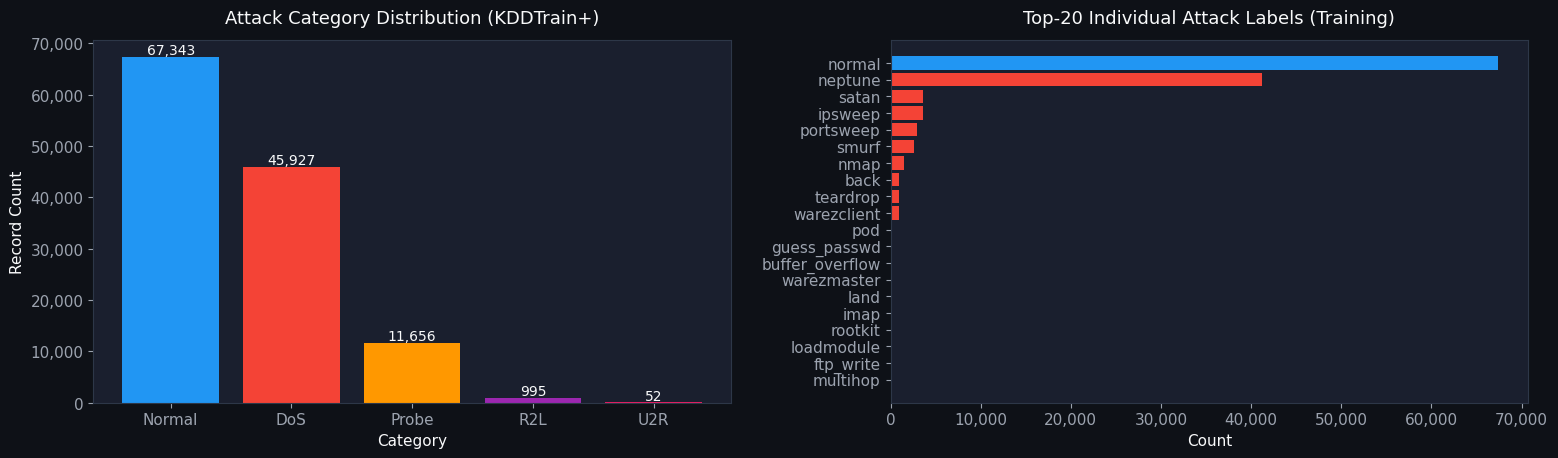


Unique attack labels in training: 23
Unique attack labels in test    : 38
Zero-day labels (test only)     : ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [5]:
# ── Attack category distribution ─────────────────────────────────────────────
cat_counts = df_train['category'].value_counts()
label_counts = df_train['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Category bar
colors_cat = [CATEGORY_COLORS.get(c, '#666') for c in cat_counts.index]
axes[0].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='none')
for i, (k, v) in enumerate(cat_counts.items()):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10, color='#F9FAFB')
axes[0].set_title('Attack Category Distribution (KDDTrain+)', fontsize=13, pad=12)
axes[0].set_xlabel('Category');  axes[0].set_ylabel('Record Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Top-20 individual labels
top20 = label_counts.head(20)
colors_lbl = [PALETTE['normal'] if l == 'normal' else PALETTE['attack'] for l in top20.index]
axes[1].barh(top20.index[::-1], top20.values[::-1], color=colors_lbl[::-1], edgecolor='none')
axes[1].set_title('Top-20 Individual Attack Labels (Training)', fontsize=13, pad=12)
axes[1].set_xlabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout(pad=2)
plt.savefig('assets/01_attack_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nUnique attack labels in training: {df_train["label"].nunique()}')
print(f'Unique attack labels in test    : {df_test["label"].nunique()}')
novel = set(df_test['label'].unique()) - set(df_train['label'].unique())
print(f'Zero-day labels (test only)     : {sorted(novel)}')

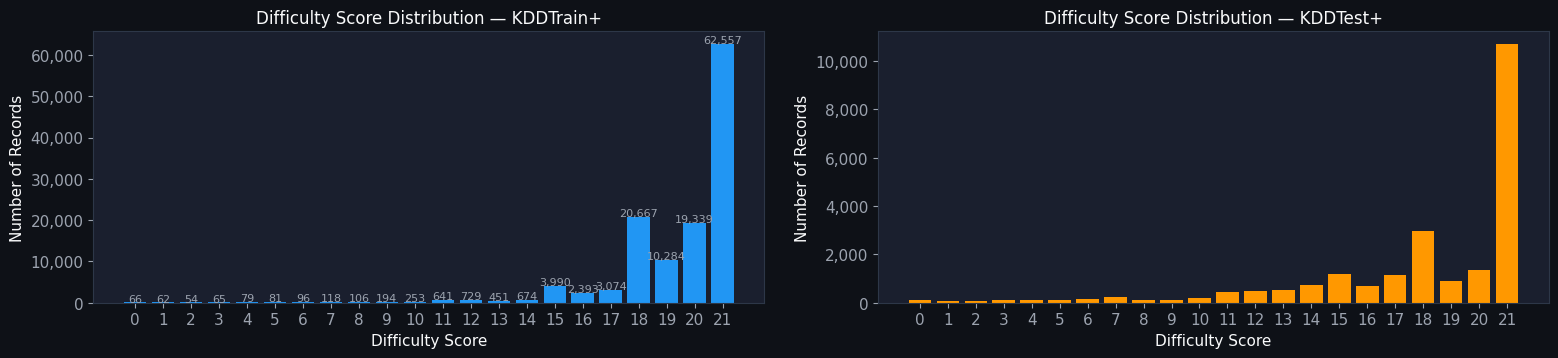

In [6]:
# ── Difficulty score distribution ────────────────────────────────────────────
diff_counts = df_train['difficulty'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Training difficulty
axes[0].bar(diff_counts.index.astype(str), diff_counts.values,
            color=PALETTE['normal'], edgecolor='none')
axes[0].set_title('Difficulty Score Distribution — KDDTrain+', fontsize=12)
axes[0].set_xlabel('Difficulty Score');  axes[0].set_ylabel('Number of Records')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar in axes[0].patches:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x()+bar.get_width()/2, h+200, f'{int(h):,}',
                     ha='center', fontsize=8, color='#9CA3AF')

# Test difficulty
diff_test = df_test['difficulty'].value_counts().sort_index()
axes[1].bar(diff_test.index.astype(str), diff_test.values,
            color=PALETTE['accent'], edgecolor='none')
axes[1].set_title('Difficulty Score Distribution — KDDTest+', fontsize=12)
axes[1].set_xlabel('Difficulty Score');  axes[1].set_ylabel('Number of Records')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout(pad=2)
plt.savefig('assets/02_difficulty_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

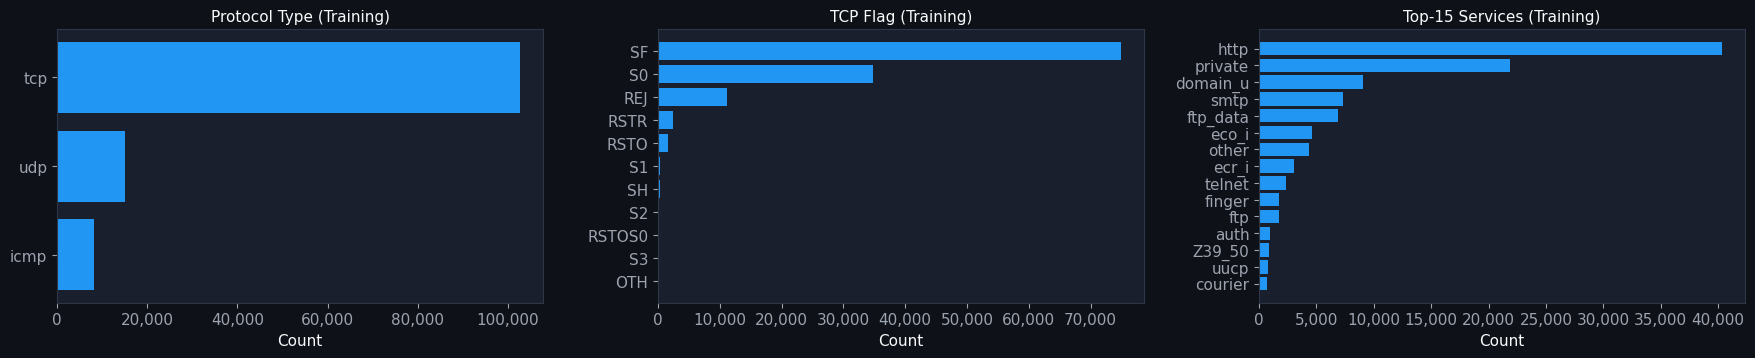

In [7]:
# ── Protocol, Service, Flag breakdown ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col, title in zip(
        axes,
        ['protocol_type', 'flag', 'service'],
        ['Protocol Type', 'TCP Flag', 'Top-15 Services']):
    if col == 'service':
        vc = df_train[col].value_counts().head(15)
    else:
        vc = df_train[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color=PALETTE['normal'], edgecolor='none')
    ax.set_title(f'{title} (Training)', fontsize=11)
    ax.set_xlabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout(pad=2)
plt.savefig('assets/03_categorical_dist.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# ── Numeric feature statistics (normal vs anomaly) ────────────────────────────
key_features = ['duration','src_bytes','dst_bytes','count','srv_count',
                'serror_rate','rerror_rate','same_srv_rate','diff_srv_rate',
                'dst_host_count','dst_host_srv_count','num_failed_logins']

stats_normal = df_train[df_train['is_anomaly']==0][key_features].describe().T[['mean','std','50%']]
stats_attack = df_train[df_train['is_anomaly']==1][key_features].describe().T[['mean','std','50%']]

stats_normal.columns = ['Normal_Mean','Normal_Std','Normal_Median']
stats_attack.columns = ['Attack_Mean','Attack_Std','Attack_Median']

comparison = pd.concat([stats_normal, stats_attack], axis=1).round(3)
print('Key Feature Statistics: Normal vs Attack Traffic')
print('='*80)
display(comparison)

Key Feature Statistics: Normal vs Attack Traffic


,Normal_Mean,Normal_Std,Normal_Median,Attack_Mean,Attack_Std,Attack_Median
duration,168.5870,1304.4520,0.0000,423.3210,3547.6850,0.0000
src_bytes,13133.2790,418113.1340,233.0000,82820.1410,8593024.6000,0.0000
dst_bytes,4329.6850,65462.8180,379.0000,37524.4820,5893990.9380,0.0000
count,22.5180,54.0260,4.0000,154.8500,124.3340,138.0000
srv_count,27.6860,60.1820,5.0000,27.7980,84.7110,10.0000
serror_rate,0.0130,0.0940,0.0000,0.5960,0.4870,1.0000
rerror_rate,0.0440,0.2030,0.0000,0.2070,0.3990,0.0000
same_srv_rate,0.9690,0.1440,1.0000,0.3070,0.3960,0.0800
diff_srv_rate,0.0290,0.1460,0.0000,0.1020,0.2060,0.0600
dst_host_count,147.4320,101.7850,156.0000,222.0250,79.1960,255.0000


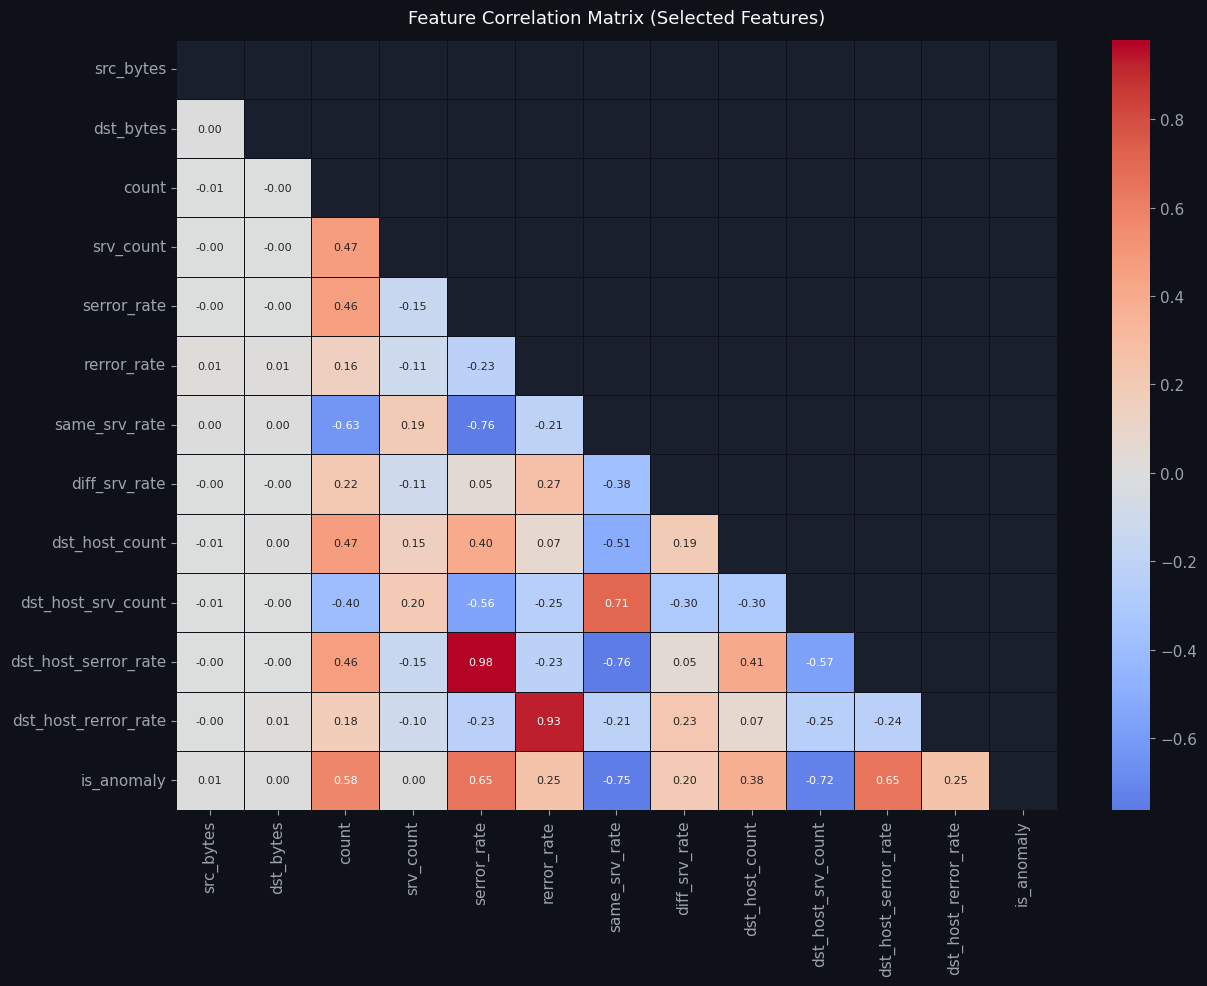

In [9]:
# ── Correlation heatmap of top numeric features ───────────────────────────────
corr_features = ['src_bytes','dst_bytes','count','srv_count','serror_rate',
                 'rerror_rate','same_srv_rate','diff_srv_rate',
                 'dst_host_count','dst_host_srv_count','dst_host_serror_rate',
                 'dst_host_rerror_rate','is_anomaly']

corr_matrix = df_train[corr_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, linecolor='#0E1117',
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (Selected Features)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('assets/04_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

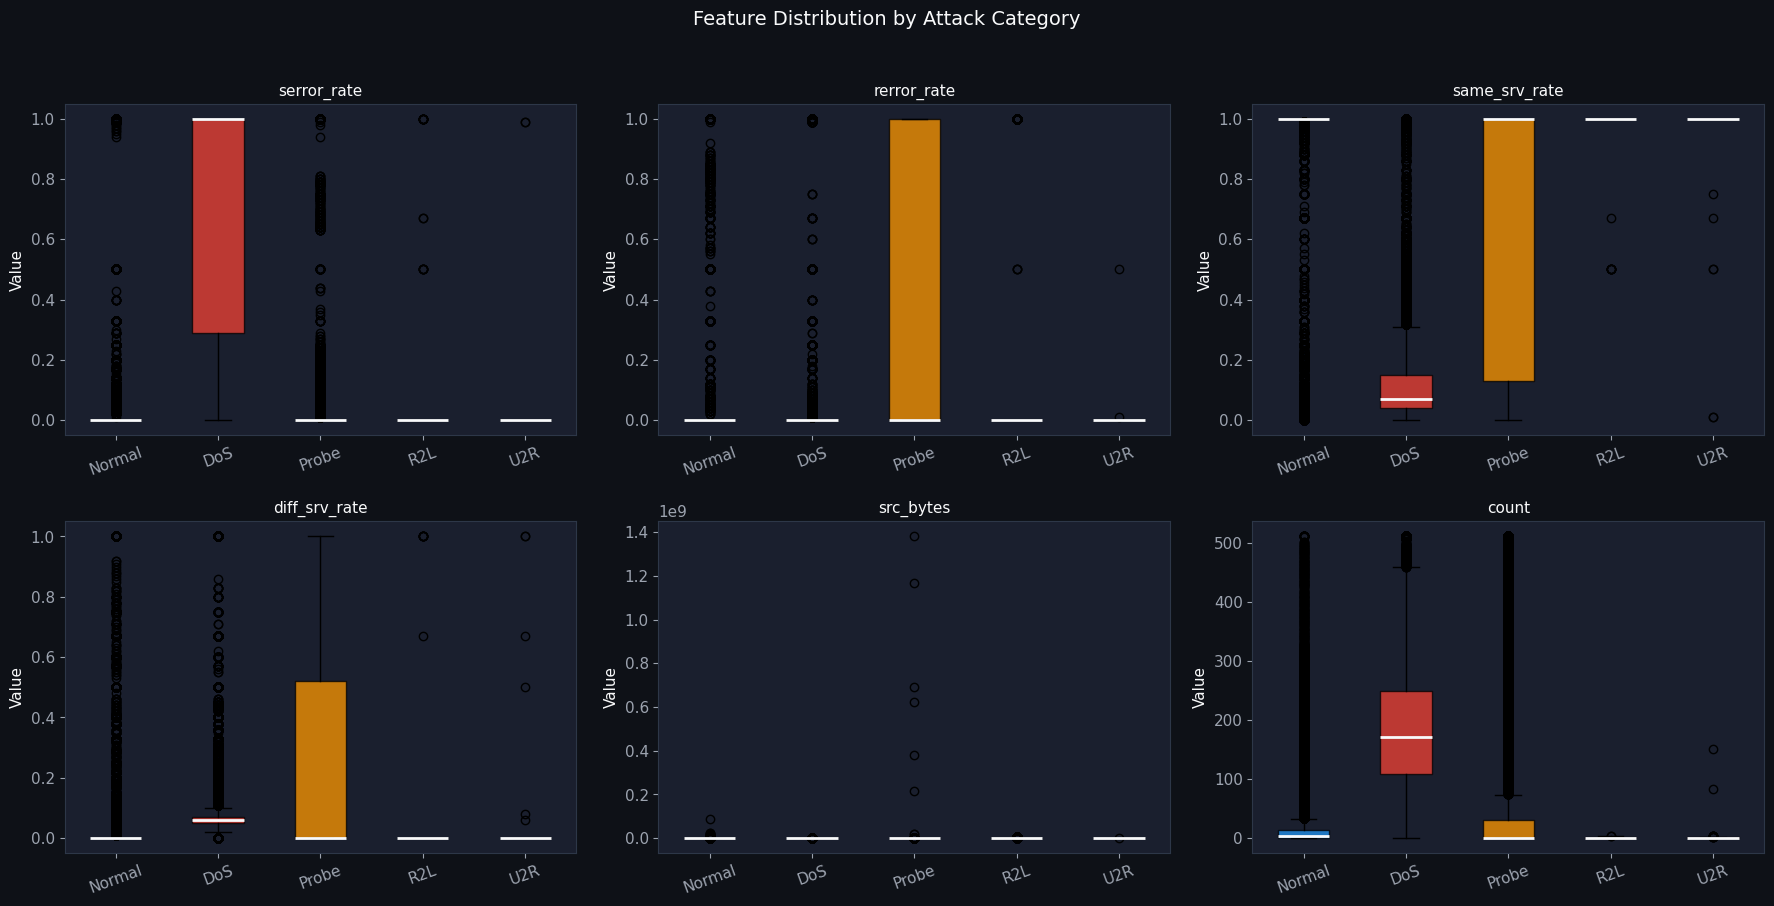

In [10]:
# ── Box plots: key features by attack category ───────────────────────────────
plot_features = ['serror_rate','rerror_rate','same_srv_rate','diff_srv_rate',
                 'src_bytes','count']
df_box = df_train[plot_features + ['category']].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
categories = ['Normal','DoS','Probe','R2L','U2R']
cat_colors = [CATEGORY_COLORS[c] for c in categories]

for ax, feat in zip(axes, plot_features):
    data_by_cat = [df_box[df_box['category']==c][feat].dropna().values
                   for c in categories]
    bp = ax.boxplot(data_by_cat, patch_artist=True, notch=False,
                    medianprops=dict(color='#F9FAFB', linewidth=2))
    for patch, color in zip(bp['boxes'], cat_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(categories, rotation=20)
    ax.set_title(f'{feat}', fontsize=11)
    ax.set_ylabel('Value')

fig.suptitle('Feature Distribution by Attack Category', fontsize=14, y=1.01)
plt.tight_layout(pad=1.5)
plt.savefig('assets/05_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔧 Section 4 — Data Preprocessing

Steps:
1. Remove duplicates
2. Label encode categorical features
3. Clip extreme outliers (99.5th percentile)
4. Min-Max normalisation
5. Train / test split

In [11]:
# ── Work on full training set ─────────────────────────────────────────────────
df_tr = df_train.copy()
df_te = df_test.copy()

print(f'Before dedup — train: {len(df_tr):,}  test: {len(df_te):,}')
df_tr.drop_duplicates(subset=COLUMNS[:-1], inplace=True)   # keep all except difficulty
df_te.drop_duplicates(subset=COLUMNS[:-1], inplace=True)
df_tr.reset_index(drop=True, inplace=True)
df_te.reset_index(drop=True, inplace=True)
print(f'After  dedup — train: {len(df_tr):,}  test: {len(df_te):,}')

# ── Label encode categoricals (fit on train, transform both) ──────────────────
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    # Fit on combined vocab to avoid unseen-label errors on test set
    combined = pd.concat([df_tr[col], df_te[col]]).astype(str)
    le.fit(combined)
    df_tr[col] = le.transform(df_tr[col].astype(str))
    df_te[col] = le.transform(df_te[col].astype(str))
    encoders[col] = le
    print(f'  Encoded {col}: {len(le.classes_)} unique values')

# ── Feature matrix ────────────────────────────────────────────────────────────
FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS

# ── Clip at 99.5th percentile (fit on training only) ─────────────────────────
caps = {}
for col in NUMERIC_COLS:
    cap = df_tr[col].quantile(0.995)
    caps[col] = cap
    df_tr[col] = df_tr[col].clip(upper=cap)
    df_te[col] = df_te[col].clip(upper=cap)

# ── Min-Max normalise (fit on training only) ──────────────────────────────────
scaler = MinMaxScaler()
X_train_raw = df_tr[FEATURE_COLS].values
X_test_raw  = df_te[FEATURE_COLS].values

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

y_train = df_tr['is_anomaly'].values
y_test  = df_te['is_anomaly'].values

print(f'\n✅ Preprocessing complete')
print(f'   X_train : {X_train_scaled.shape}  |  y_train anomaly rate: {y_train.mean()*100:.1f}%')
print(f'   X_test  : {X_test_scaled.shape}   |  y_test  anomaly rate: {y_test.mean()*100:.1f}%')

Before dedup — train: 125,973  test: 22,544
After  dedup — train: 125,973  test: 22,544
  Encoded protocol_type: 3 unique values
  Encoded service: 70 unique values
  Encoded flag: 11 unique values



✅ Preprocessing complete
   X_train : (125973, 41)  |  y_train anomaly rate: 46.5%
   X_test  : (22544, 41)   |  y_test  anomaly rate: 56.9%


## ⚙️ Section 5 — Feature Engineering & PCA

In [12]:
# ── Mutual Information feature importance ─────────────────────────────────────
print('Computing Mutual Information scores (this may take ~30 seconds) …')
t0 = time.time()
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42, n_jobs=-1)
print(f'Done in {time.time()-t0:.1f}s')

importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)
importance_df['Rank'] = importance_df.index + 1

print('\nTop-20 Features by Mutual Information:')
display(importance_df.head(20))

Computing Mutual Information scores (this may take ~30 seconds) …


Done in 20.3s

Top-20 Features by Mutual Information:


,Feature,MI_Score,Rank
0,src_bytes,0.5588,1
1,service,0.4690,2
2,dst_bytes,0.4404,3
3,flag,0.3684,4
4,same_srv_rate,0.3669,5
5,diff_srv_rate,0.3594,6
6,dst_host_srv_count,0.3371,7
7,dst_host_same_srv_rate,0.3126,8
8,logged_in,0.2915,9
9,dst_host_diff_srv_rate,0.2862,10


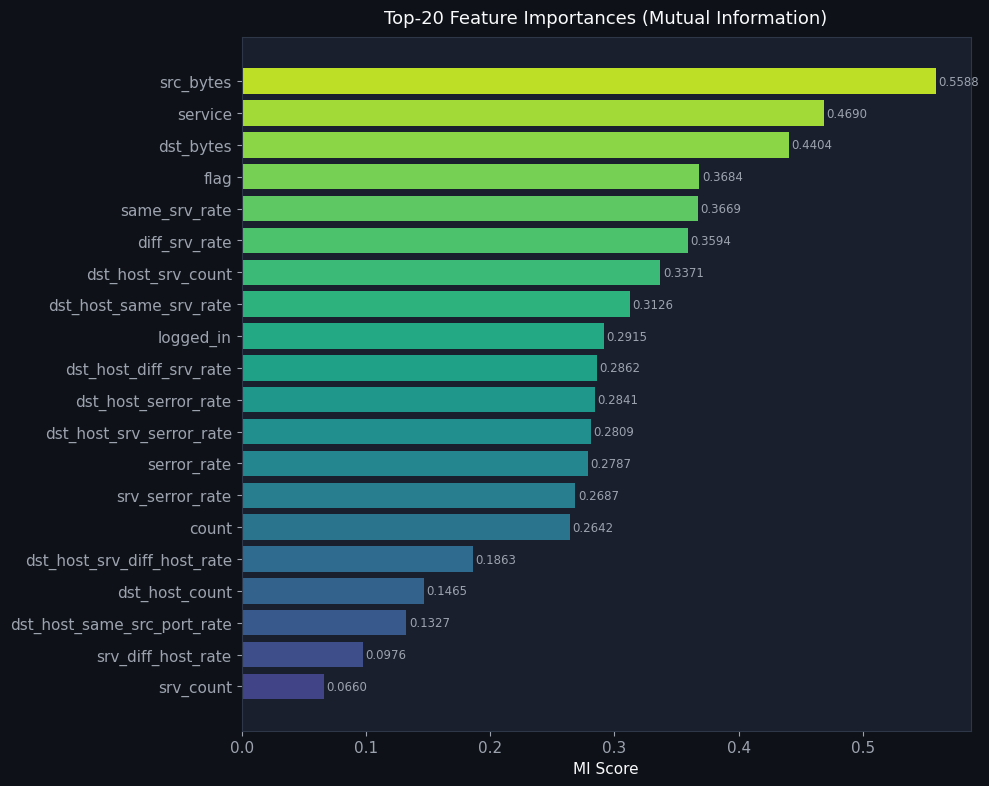

In [13]:
# ── Feature importance plot ───────────────────────────────────────────────────
top_n = 20
df_imp = importance_df.head(top_n).sort_values('MI_Score')

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(df_imp['Feature'], df_imp['MI_Score'],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, top_n)),
               edgecolor='none')
for bar, val in zip(bars, df_imp['MI_Score']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5, color='#9CA3AF')

ax.set_title(f'Top-{top_n} Feature Importances (Mutual Information)', fontsize=13, pad=10)
ax.set_xlabel('MI Score');  ax.set_ylabel('')
plt.tight_layout()
plt.savefig('assets/06_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# ── Select top-20 features, then apply PCA ───────────────────────────────────
TOP_FEATURES = importance_df.head(20)['Feature'].tolist()
top_indices  = [FEATURE_COLS.index(f) for f in TOP_FEATURES]

X_train_sel = X_train_scaled[:, top_indices]
X_test_sel  = X_test_scaled[:, top_indices]

# PCA — retain 95% variance
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca  = pca.transform(X_test_sel)

evr     = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

print(f'PCA Results')
print(f'  Input dimensions  : {X_train_sel.shape[1]}')
print(f'  Components kept   : {pca.n_components_}')
print(f'  Variance retained : {cum_evr[-1]*100:.2f}%')
print(f'  X_train_pca shape : {X_train_pca.shape}')
print(f'  X_test_pca  shape : {X_test_pca.shape}')

PCA Results
  Input dimensions  : 20
  Components kept   : 10
  Variance retained : 96.07%
  X_train_pca shape : (125973, 10)
  X_test_pca  shape : (22544, 10)


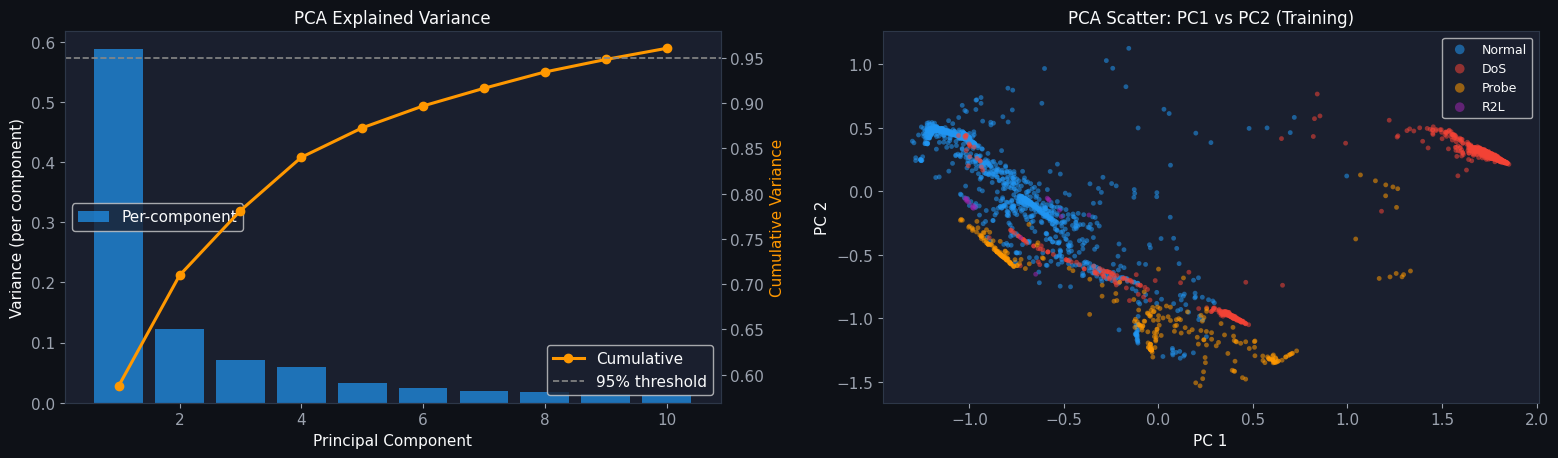

In [15]:
# ── PCA variance + scatter ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Variance explained
axes[0].bar(range(1, len(evr)+1), evr, color=PALETTE['normal'], alpha=0.7,
             label='Per-component', edgecolor='none')
ax2 = axes[0].twinx()
ax2.plot(range(1, len(evr)+1), cum_evr, 'o-', color=PALETTE['accent'],
          linewidth=2.2, markersize=6, label='Cumulative')
ax2.axhline(0.95, color='#888', linestyle='--', linewidth=1.2, label='95% threshold')
ax2.set_ylabel('Cumulative Variance', color=PALETTE['accent'])
axes[0].set_xlabel('Principal Component');  axes[0].set_ylabel('Variance (per component)')
axes[0].set_title('PCA Explained Variance', fontsize=12)
axes[0].legend(loc='center left');  ax2.legend(loc='lower right')

# PC1 vs PC2 scatter (sample 3000 points)
idx_sample = np.random.choice(len(X_train_pca), min(3000, len(X_train_pca)), replace=False)
cat_labels = df_tr['category'].values[idx_sample]
pc1, pc2   = X_train_pca[idx_sample, 0], X_train_pca[idx_sample, 1]

for cat in ['Normal','DoS','Probe','R2L','U2R']:
    mask = cat_labels == cat
    if mask.sum() > 0:
        axes[1].scatter(pc1[mask], pc2[mask],
                        c=CATEGORY_COLORS[cat], label=cat,
                        alpha=0.55, s=12, edgecolors='none')

axes[1].set_xlabel('PC 1');  axes[1].set_ylabel('PC 2')
axes[1].set_title('PCA Scatter: PC1 vs PC2 (Training)', fontsize=12)
axes[1].legend(markerscale=2, fontsize=9)

plt.tight_layout(pad=2)
plt.savefig('assets/07_pca.png', dpi=120, bbox_inches='tight')
plt.show()

## 🌲 Section 6 — Isolation Forest Model Training

### Why Isolation Forest?

| Property | Detail |
|----------|--------|
| **Type** | Unsupervised anomaly detection — no labels needed |
| **Mechanism** | Random recursive partitioning; anomalies isolated in fewer steps |
| **Score** | `s(x,n) = 2^(−E[h(x)] / c(n))` — closer to 1.0 → more anomalous |
| **Complexity** | O(n log n) — efficient on large datasets |
| **Key param** | `contamination` — expected fraction of anomalies |

In [16]:
# ── Estimate contamination from training data ─────────────────────────────────
contamination = round(float(y_train.mean()), 2)
contamination = min(max(contamination, 0.01), 0.49)   # clamp to valid range
print(f'Estimated contamination from training labels: {contamination:.2f}')

# ── Train Isolation Forest ────────────────────────────────────────────────────
print('\nTraining Isolation Forest …')
t0 = time.time()

clf = IsolationForest(
    n_estimators  = 200,
    contamination = contamination,
    max_features  = 1.0,
    max_samples   = 'auto',
    bootstrap     = False,
    random_state  = 42,
    n_jobs        = -1,
)
clf.fit(X_train_pca)
elapsed = time.time() - t0

print(f'Training complete in {elapsed:.1f}s')
print(f'  n_estimators : {clf.n_estimators}')
print(f'  contamination: {clf.contamination}')
print(f'  n_features   : {clf.n_features_in_}')
print(f'  offset_       : {clf.offset_:.4f}')

# Save model
os.makedirs('models', exist_ok=True)
with open('models/isolation_forest.pkl', 'wb') as f:
    pickle.dump({'model': clf, 'scaler': scaler, 'pca': pca,
                 'encoders': encoders, 'features': TOP_FEATURES}, f)
print('\n✅ Model saved → models/isolation_forest.pkl')

Estimated contamination from training labels: 0.47

Training Isolation Forest …


Training complete in 1.4s
  n_estimators : 200
  contamination: 0.47
  n_features   : 10
  offset_       : -0.4329

✅ Model saved → models/isolation_forest.pkl


## 🎯 Section 7 — Anomaly Detection & Scoring

In [17]:
# ── Predict on TEST set ───────────────────────────────────────────────────────
raw_preds  = clf.predict(X_test_pca)          # -1 = anomaly, +1 = normal
y_pred     = (raw_preds == -1).astype(int)    # 1 = anomaly
raw_scores = clf.score_samples(X_test_pca)    # lower  = more anomalous

# Normalise scores to [0,1] : higher = more anomalous
scores_norm = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
scores_norm = 1.0 - scores_norm    # flip so 1 = most anomalous

print('Anomaly Score Statistics (Test Set)')
print(f'  Normal  records — mean score: {scores_norm[y_test==0].mean():.4f}')
print(f'  Anomaly records — mean score: {scores_norm[y_test==1].mean():.4f}')
print(f'\nPredicted anomalies : {y_pred.sum():,}  ({y_pred.mean()*100:.1f}%)')
print(f'Actual    anomalies : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')

# Attach results to test dataframe for analysis
df_results = df_te.copy()
df_results['anomaly_score'] = scores_norm
df_results['predicted']     = y_pred
df_results['correct']       = (y_pred == y_test).astype(int)

Anomaly Score Statistics (Test Set)
  Normal  records — mean score: 0.1866
  Anomaly records — mean score: 0.3959

Predicted anomalies : 13,590  (60.3%)
Actual    anomalies : 12,833  (56.9%)


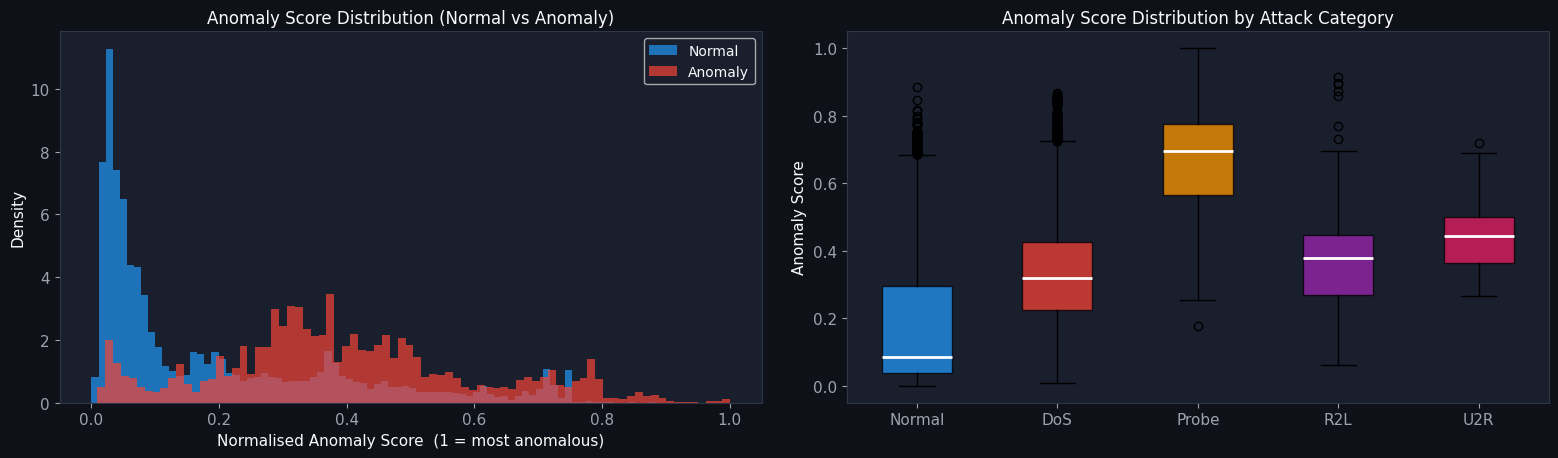

In [18]:
# ── Anomaly score distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram: normal vs anomaly
axes[0].hist(scores_norm[y_test==0], bins=80, color=PALETTE['normal'],
              alpha=0.70, density=True, label='Normal')
axes[0].hist(scores_norm[y_test==1], bins=80, color=PALETTE['attack'],
              alpha=0.70, density=True, label='Anomaly')
axes[0].set_title('Anomaly Score Distribution (Normal vs Anomaly)', fontsize=12)
axes[0].set_xlabel('Normalised Anomaly Score  (1 = most anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=10)

# Box plots per category
categories = ['Normal','DoS','Probe','R2L','U2R']
score_by_cat = [df_results[df_results['category']==c]['anomaly_score'].values
                for c in categories]
bp = axes[1].boxplot(score_by_cat, patch_artist=True, notch=False,
                      medianprops=dict(color='white', linewidth=2))
for patch, cat in zip(bp['boxes'], categories):
    patch.set_facecolor(CATEGORY_COLORS[cat])
    patch.set_alpha(0.75)
axes[1].set_xticklabels(categories)
axes[1].set_title('Anomaly Score Distribution by Attack Category', fontsize=12)
axes[1].set_ylabel('Anomaly Score')

plt.tight_layout(pad=2)
plt.savefig('assets/08_score_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

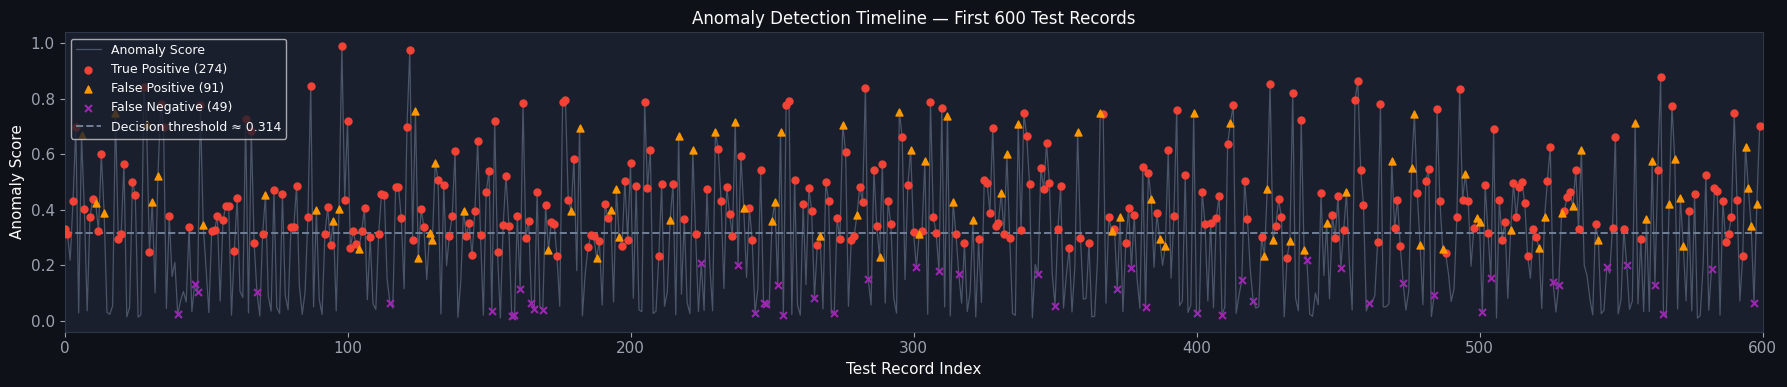

In [19]:
# ── Anomaly score timeline (first 600 test records) ───────────────────────────
N = 600
x_idx = np.arange(N)
sc_slice = scores_norm[:N]
pr_slice = y_pred[:N]
gt_slice = y_test[:N]

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(x_idx, sc_slice, color='#4A5568', linewidth=0.9, label='Anomaly Score')

# True anomalies
tp_mask = (pr_slice==1) & (gt_slice==1)
fp_mask = (pr_slice==1) & (gt_slice==0)
fn_mask = (pr_slice==0) & (gt_slice==1)

ax.scatter(x_idx[tp_mask], sc_slice[tp_mask], c=PALETTE['attack'],
            s=25, zorder=5, label=f'True Positive ({tp_mask.sum()})')
ax.scatter(x_idx[fp_mask], sc_slice[fp_mask], c=PALETTE['accent'],
            s=25, marker='^', zorder=5, label=f'False Positive ({fp_mask.sum()})')
ax.scatter(x_idx[fn_mask], sc_slice[fn_mask], c='#9C27B0',
            s=25, marker='x', zorder=5, label=f'False Negative ({fn_mask.sum()})')

thresh_val = np.percentile(scores_norm, (1-contamination)*100)
ax.axhline(thresh_val, color='#718096', linestyle='--', linewidth=1.4,
            label=f'Decision threshold ≈ {thresh_val:.3f}')
ax.set_xlabel('Test Record Index');  ax.set_ylabel('Anomaly Score')
ax.set_title('Anomaly Detection Timeline — First 600 Test Records', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0, N)
plt.tight_layout()
plt.savefig('assets/09_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

## 📊 Section 8 — Performance Evaluation

In [20]:
# ── Core metrics ──────────────────────────────────────────────────────────────
acc   = accuracy_score(y_test, y_pred) * 100
prec  = precision_score(y_test, y_pred, zero_division=0) * 100
rec   = recall_score(y_test, y_pred, zero_division=0) * 100
f1    = f1_score(y_test, y_pred, zero_division=0) * 100
auc   = roc_auc_score(y_test, scores_norm) * 100
ap    = average_precision_score(y_test, scores_norm) * 100

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
fpr_rate = fp / (fp + tn + 1e-9) * 100
fnr_rate = fn / (fn + tp + 1e-9) * 100
spec     = tn / (tn + fp + 1e-9) * 100
dr       = tp / (tp + fn + 1e-9) * 100

print('=' * 55)
print('  ZERO-DAY IDS — EVALUATION REPORT (NSL-KDD)')
print('=' * 55)
print(f'  Accuracy          : {acc:.2f} %')
print(f'  Precision         : {prec:.2f} %')
print(f'  Recall (DR)       : {rec:.2f} %')
print(f'  F1-Score          : {f1:.2f} %')
print(f'  ROC-AUC           : {auc:.2f} %')
print(f'  Avg Precision     : {ap:.2f} %')
print('─' * 55)
print(f'  True  Positives   : {tp:,}')
print(f'  True  Negatives   : {tn:,}')
print(f'  False Positives   : {fp:,}')
print(f'  False Negatives   : {fn:,}')
print('─' * 55)
print(f'  Specificity       : {spec:.2f} %')
print(f'  Detection Rate    : {dr:.2f} %')
print(f'  False Pos. Rate   : {fpr_rate:.2f} %')
print(f'  False Neg. Rate   : {fnr_rate:.2f} %')
print('=' * 55)

  ZERO-DAY IDS — EVALUATION REPORT (NSL-KDD)
  Accuracy          : 76.65 %
  Precision         : 77.84 %
  Recall (DR)       : 82.44 %
  F1-Score          : 80.07 %
  ROC-AUC           : 78.31 %
  Avg Precision     : 78.58 %
───────────────────────────────────────────────────────
  True  Positives   : 10,579
  True  Negatives   : 6,700
  False Positives   : 3,011
  False Negatives   : 2,254
───────────────────────────────────────────────────────
  Specificity       : 68.99 %
  Detection Rate    : 82.44 %
  False Pos. Rate   : 31.01 %
  False Neg. Rate   : 17.56 %


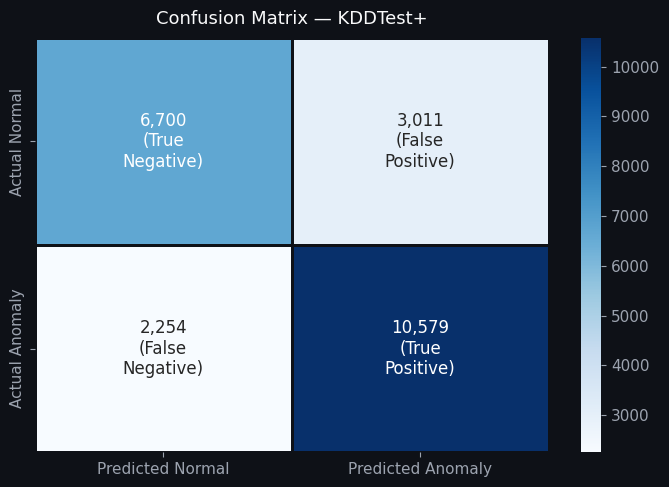

In [21]:
# ── Confusion matrix heatmap ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
cm_labels = np.array([['True\nNegative','False\nPositive'],
                       ['False\nNegative','True\nPositive']])

annot = np.array([[f'{cm[i,j]:,}\n({cm_labels[i,j]})' for j in range(2)] for i in range(2)])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['Predicted Normal','Predicted Anomaly'],
            yticklabels=['Actual Normal','Actual Anomaly'],
            linewidths=2, linecolor='#0E1117', ax=ax,
            annot_kws={'size': 12})
ax.set_title('Confusion Matrix — KDDTest+', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('assets/10_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

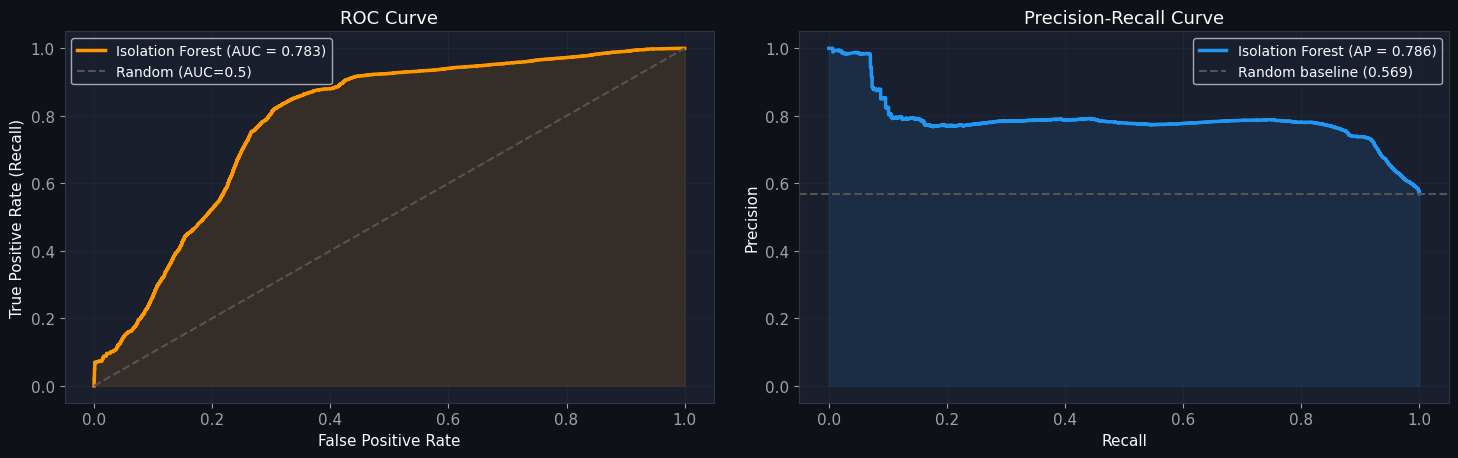

In [22]:
# ── ROC Curve + Precision-Recall Curve ───────────────────────────────────────
fpr_arr, tpr_arr, _ = roc_curve(y_test, scores_norm)
prec_arr, rec_arr, _ = precision_recall_curve(y_test, scores_norm)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC
axes[0].plot(fpr_arr, tpr_arr, color=PALETTE['accent'], linewidth=2.5,
              label=f'Isolation Forest (AUC = {auc/100:.3f})')
axes[0].plot([0,1],[0,1], '--', color='#555', linewidth=1.5, label='Random (AUC=0.5)')
axes[0].fill_between(fpr_arr, tpr_arr, alpha=0.12, color=PALETTE['accent'])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# PR
axes[1].plot(rec_arr, prec_arr, color=PALETTE['normal'], linewidth=2.5,
              label=f'Isolation Forest (AP = {ap/100:.3f})')
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='#555', linewidth=1.5,
                 label=f'Random baseline ({baseline:.3f})')
axes[1].fill_between(rec_arr, prec_arr, alpha=0.12, color=PALETTE['normal'])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=2)
plt.savefig('assets/11_roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

,Category,Total,Correctly Flagged,Detection Rate %
0,Normal,9711,6700,69.0000
1,DoS,7460,5597,75.0000
2,Probe,2421,2420,100.0000
3,R2L,2885,2495,86.5000
4,U2R,67,67,100.0000


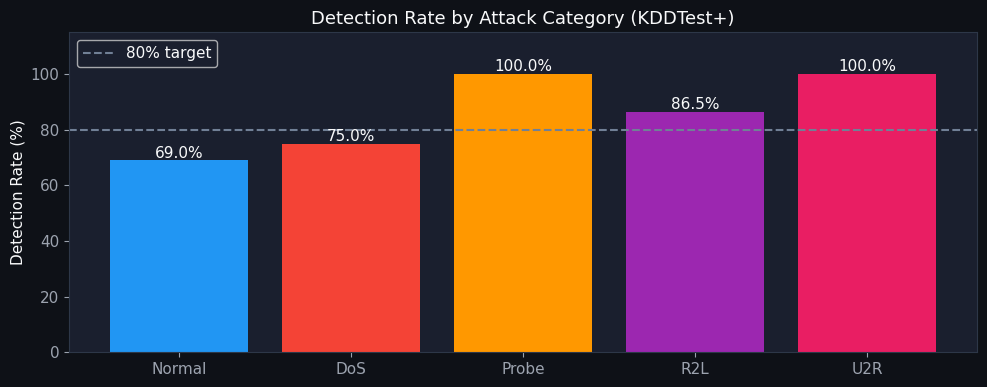

In [23]:
# ── Per-attack-type detection rate ────────────────────────────────────────────
rows = []
for cat in ['Normal','DoS','Probe','R2L','U2R']:
    mask  = df_results['category'] == cat
    total = mask.sum()
    if total == 0:
        continue
    if cat == 'Normal':
        detected = int((df_results.loc[mask, 'predicted'] == 0).sum())
    else:
        detected = int((df_results.loc[mask, 'predicted'] == 1).sum())
    rows.append({
        'Category':       cat,
        'Total':          int(total),
        'Correctly Flagged': detected,
        'Detection Rate %': round(detected/total*100, 1)
    })

breakdown_df = pd.DataFrame(rows)
display(breakdown_df)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors  = [CATEGORY_COLORS[c] for c in breakdown_df['Category']]
bars    = ax.bar(breakdown_df['Category'], breakdown_df['Detection Rate %'],
                  color=colors, edgecolor='none')
for bar, val in zip(bars, breakdown_df['Detection Rate %']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', fontsize=11, color='#F9FAFB')
ax.axhline(80, linestyle='--', color='#718096', linewidth=1.5, label='80% target')
ax.set_ylim(0, 115)
ax.set_title('Detection Rate by Attack Category (KDDTest+)', fontsize=13)
ax.set_ylabel('Detection Rate (%)'); ax.legend()
plt.tight_layout()
plt.savefig('assets/12_detection_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

In [24]:
# ── Per-label detection rate (all 38 labels in test set) ─────────────────────
label_rows = []
for lbl in sorted(df_results['label'].unique()):
    mask  = df_results['label'] == lbl
    total = mask.sum()
    if total == 0:
        continue
    if lbl == 'normal':
        detected = int((df_results.loc[mask, 'predicted'] == 0).sum())
        note     = 'Correctly kept as normal'
    else:
        detected = int((df_results.loc[mask, 'predicted'] == 1).sum())
        note     = 'Detected as anomaly'
        # Mark zero-day (not in training)
        if lbl not in df_train['label'].values:
            note += ' ⭐ (Zero-Day)'
    label_rows.append({
        'Label':        lbl,
        'Category':     ATTACK_MAP.get(lbl, 'Unknown'),
        'Total':        int(total),
        'Detected':     detected,
        'Det. Rate %':  round(detected/total*100, 1),
        'Note':         note
    })

label_df = pd.DataFrame(label_rows).sort_values('Det. Rate %', ascending=False)
print(f'Total labels in test set: {len(label_df)}')
display(label_df)

Total labels in test set: 38


,Label,Category,Total,Detected,Det. Rate %,Note
3,ftp_write,R2L,3,3,100.0000,Detected as anomaly
2,buffer_overflow,U2R,20,20,100.0000,Detected as anomaly
9,loadmodule,U2R,2,2,100.0000,Detected as anomaly
8,land,DoS,7,7,100.0000,Detected as anomaly
7,ipsweep,Probe,141,141,100.0000,Detected as anomaly
6,imap,R2L,1,1,100.0000,Detected as anomaly
36,xsnoop,R2L,4,4,100.0000,Detected as anomaly ⭐ (Zero-Day)
31,teardrop,DoS,12,12,100.0000,Detected as anomaly
32,udpstorm,DoS,2,2,100.0000,Detected as anomaly ⭐ (Zero-Day)
34,worm,DoS,2,2,100.0000,Detected as anomaly ⭐ (Zero-Day)


## 🎨 Section 9 — Advanced Visualizations

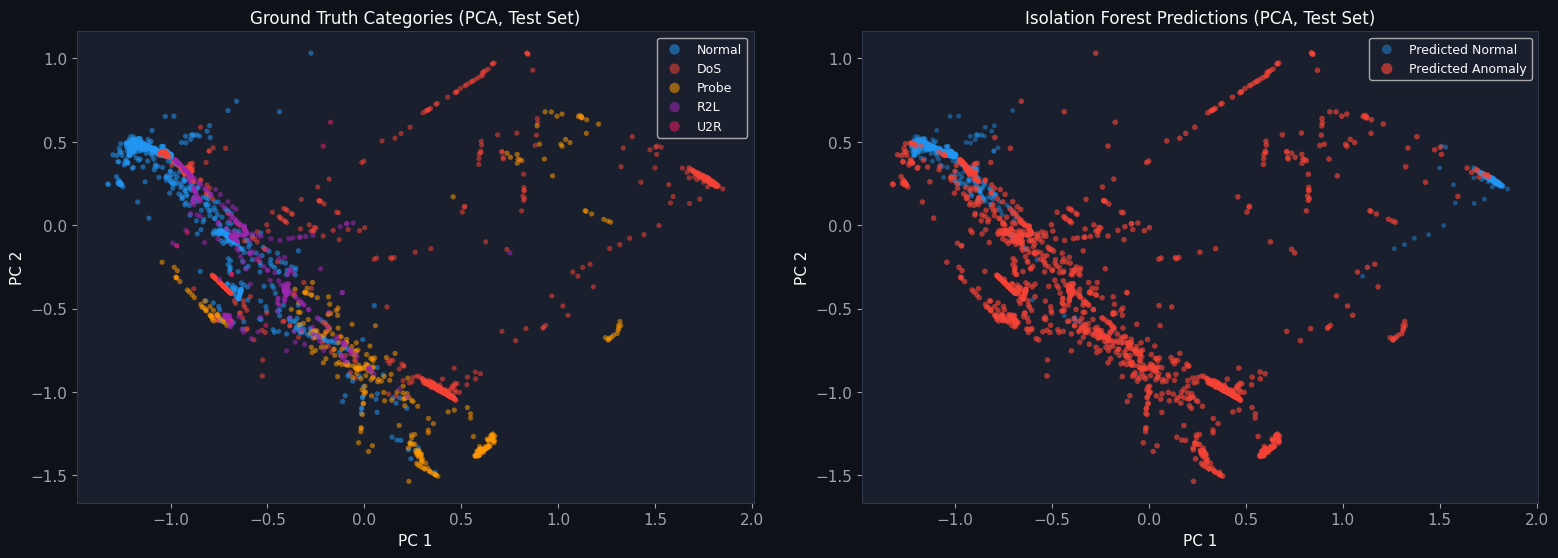

In [25]:
# ── PCA scatter — Test set: True vs Predicted ─────────────────────────────────
idx_s  = np.random.choice(len(X_test_pca), min(3000, len(X_test_pca)), replace=False)
pc1_te = X_test_pca[idx_s, 0]
pc2_te = X_test_pca[idx_s, 1]
cat_te = df_results['category'].values[idx_s]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ground truth
for cat in ['Normal','DoS','Probe','R2L','U2R']:
    m = cat_te == cat
    if m.sum() > 0:
        axes[0].scatter(pc1_te[m], pc2_te[m], c=CATEGORY_COLORS[cat],
                         label=cat, alpha=0.55, s=14, edgecolors='none')
axes[0].set_title('Ground Truth Categories (PCA, Test Set)', fontsize=12)
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=2, fontsize=9)

# Predicted
pred_te = y_pred[idx_s]
axes[1].scatter(pc1_te[pred_te==0], pc2_te[pred_te==0],
                 c=PALETTE['normal'], label='Predicted Normal',
                 alpha=0.45, s=12, edgecolors='none')
axes[1].scatter(pc1_te[pred_te==1], pc2_te[pred_te==1],
                 c=PALETTE['attack'], label='Predicted Anomaly',
                 alpha=0.65, s=16, edgecolors='none')
axes[1].set_title('Isolation Forest Predictions (PCA, Test Set)', fontsize=12)
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2, fontsize=9)

plt.tight_layout(pad=2)
plt.savefig('assets/13_pca_test_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

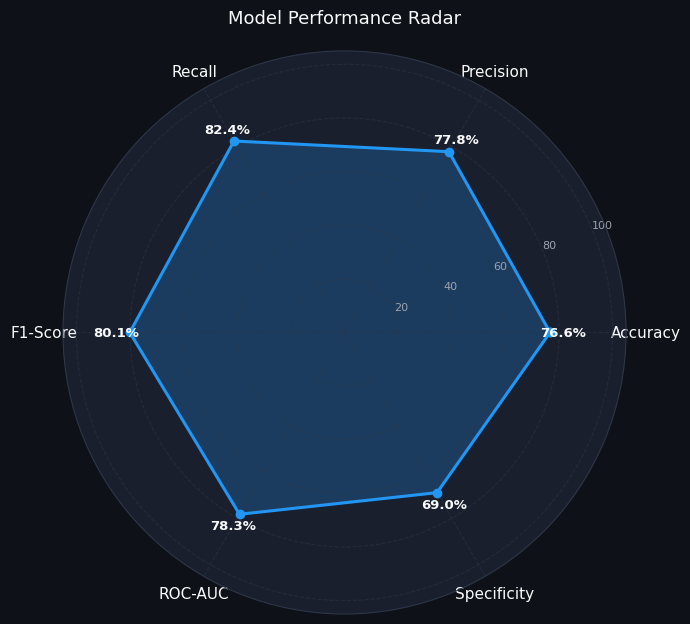

In [26]:
# ── Metrics radar / spider chart ──────────────────────────────────────────────
metrics_names  = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Specificity']
metrics_values = [acc, prec, rec, f1, auc, spec]

angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
values = metrics_values + [metrics_values[0]]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
ax.set_facecolor('#1A1F2E')
fig.patch.set_facecolor('#0E1117')

ax.plot(angles, values, 'o-', linewidth=2.2, color=PALETTE['normal'])
ax.fill(angles, values, alpha=0.25, color=PALETTE['normal'])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_names, fontsize=11, color='#F9FAFB')
ax.set_ylim(0, 105)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=8, color='#9CA3AF')
ax.yaxis.grid(color='#2D3748', linestyle='--', linewidth=0.8)
ax.xaxis.grid(color='#2D3748', linestyle='--', linewidth=0.8)

for angle, val, name in zip(angles[:-1], metrics_values, metrics_names):
    ax.text(angle, val + 5, f'{val:.1f}%', ha='center', va='center',
            fontsize=9.5, color='#F9FAFB', fontweight='bold')

ax.set_title('Model Performance Radar', fontsize=13, pad=20, color='#F9FAFB')
plt.tight_layout()
plt.savefig('assets/14_radar_chart.png', dpi=120, bbox_inches='tight')
plt.show()

In [27]:
# ── Interactive Plotly dashboard ─────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Traffic Overview', 'Attack Distribution',
        'Anomaly Score Histogram', 'Confusion Matrix',
        'ROC Curve', 'Detection Rate by Category',
    ),
    specs=[[{'type':'pie'}, {'type':'bar'}, {'type':'histogram'}],
           [{'type':'heatmap'}, {'type':'scatter'}, {'type':'bar'}]]
)

n_normal  = int((y_test==0).sum())
n_anomaly = int((y_test==1).sum())

# 1. Pie
fig.add_trace(go.Pie(labels=['Normal','Anomaly'],
                      values=[n_normal, n_anomaly], hole=0.45,
                      marker_colors=['#2196F3','#F44336'],
                      textinfo='percent+label'), row=1, col=1)

# 2. Attack bar
cat_vc = df_results[df_results['label']!='normal']['category'].value_counts()
fig.add_trace(go.Bar(x=cat_vc.index, y=cat_vc.values,
                      marker_color=['#F44336','#FF9800','#9C27B0','#E91E63'],
                      showlegend=False), row=1, col=2)

# 3. Score histogram
fig.add_trace(go.Histogram(x=scores_norm[y_test==0], name='Normal',
                             marker_color='#2196F3', opacity=0.7,
                             nbinsx=60), row=1, col=3)
fig.add_trace(go.Histogram(x=scores_norm[y_test==1], name='Anomaly',
                             marker_color='#F44336', opacity=0.7,
                             nbinsx=60), row=1, col=3)

# 4. Confusion matrix heatmap
cm_vals = [[int(tn), int(fp)], [int(fn), int(tp)]]
fig.add_trace(go.Heatmap(
    z=cm_vals, text=[[f'{v:,}' for v in row] for row in cm_vals],
    texttemplate='<b>%{text}</b>',
    x=['Pred Normal','Pred Anomaly'], y=['Act Normal','Act Anomaly'],
    colorscale='Blues', showscale=False), row=2, col=1)

# 5. ROC curve
fig.add_trace(go.Scatter(x=fpr_arr, y=tpr_arr, mode='lines',
                          line=dict(color='#FF9800', width=2.5),
                          name=f'AUC={auc/100:.3f}',
                          showlegend=True), row=2, col=2)
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines',
                          line=dict(color='#555', dash='dash', width=1.5),
                          showlegend=False), row=2, col=2)

# 6. Detection rate bars
fig.add_trace(go.Bar(
    x=breakdown_df['Category'],
    y=breakdown_df['Detection Rate %'],
    marker_color=[CATEGORY_COLORS[c] for c in breakdown_df['Category']],
    text=[f"{v}%" for v in breakdown_df['Detection Rate %']],
    textposition='outside', showlegend=False), row=2, col=3)

fig.update_layout(
    height=700, title_text='Zero-Day IDS — Interactive Dashboard (NSL-KDD)',
    paper_bgcolor='#0E1117', plot_bgcolor='#1A1F2E',
    font=dict(color='#F9FAFB', size=11),
    barmode='overlay',
)
fig.update_xaxes(gridcolor='#2D3748'); fig.update_yaxes(gridcolor='#2D3748')
fig.show()

In [28]:
# ── Top 30 highest-scoring anomalies ─────────────────────────────────────────
cols_show = ['label','category','anomaly_score','src_bytes','dst_bytes',
              'duration','protocol_type','flag','predicted','correct']

top_anomalies = (
    df_results[df_results['predicted']==1]
    .sort_values('anomaly_score', ascending=False)
    .head(30)[cols_show]
    .reset_index(drop=True)
)
print('Top-30 Detected Anomalies (Highest Anomaly Scores)')
display(top_anomalies)

Top-30 Detected Anomalies (Highest Anomaly Scores)


,label,category,anomaly_score,src_bytes,dst_bytes,duration,protocol_type,flag,predicted,correct
0,nmap,Probe,1.0000,0,0,0.0000,1,10,1,1
1,nmap,Probe,0.9984,0,0,0.0000,1,10,1,1
2,nmap,Probe,0.9983,0,0,0.0000,1,10,1,1
3,nmap,Probe,0.9962,0,0,0.0000,1,10,1,1
4,nmap,Probe,0.9962,0,0,0.0000,1,10,1,1
5,nmap,Probe,0.9931,0,0,0.0000,1,10,1,1
6,nmap,Probe,0.9913,0,0,0.0000,1,10,1,1
7,mscan,Probe,0.9913,0,36,8.0000,1,2,1,1
8,nmap,Probe,0.9901,0,0,0.0000,1,10,1,1
9,nmap,Probe,0.9899,0,0,0.0000,1,10,1,1


In [29]:
# ── Zero-day attack analysis ──────────────────────────────────────────────────
zero_day_labels = sorted(set(df_test['label'].unique()) - set(df_train['label'].unique()))

print(f'Zero-day attack labels (present in test, absent in training):')
print(f'Count: {len(zero_day_labels)}')
print()

zd_rows = []
for lbl in zero_day_labels:
    mask     = df_results['label'] == lbl
    total    = mask.sum()
    detected = int((df_results.loc[mask, 'predicted'] == 1).sum())
    zd_rows.append({
        'Zero-Day Label': lbl,
        'Category':       ATTACK_MAP.get(lbl, 'Unknown'),
        'Records':        int(total),
        'Detected':       detected,
        'Detection Rate': f'{detected/max(total,1)*100:.1f}%'
    })

zd_df = pd.DataFrame(zd_rows)
display(zd_df)

# Summary
total_zd  = zd_df['Records'].sum()
total_det = zd_df['Detected'].sum()
print(f'\n🛡️ Overall Zero-Day Detection Rate: {total_det}/{total_zd} '
      f'= {total_det/max(total_zd,1)*100:.1f}%')

Zero-day attack labels (present in test, absent in training):
Count: 17



,Zero-Day Label,Category,Records,Detected,Detection Rate
0,apache2,DoS,737,502,68.1%
1,httptunnel,R2L,133,132,99.2%
2,mailbomb,DoS,293,287,98.0%
3,mscan,Probe,996,996,100.0%
4,named,R2L,17,17,100.0%
5,processtable,DoS,685,685,100.0%
6,ps,U2R,15,15,100.0%
7,saint,Probe,319,318,99.7%
8,sendmail,R2L,14,14,100.0%
9,snmpgetattack,R2L,178,178,100.0%



🛡️ Overall Zero-Day Detection Rate: 3507/3750 = 93.5%


## ✅ Section 10 — Results Summary & Conclusions

In [30]:
# ── Comprehensive final summary ────────────────────────────────────────────────
print('=' * 65)
print('   ZERO-DAY ANOMALY DETECTION IDS — FINAL RESULTS')
print('   Dataset: NSL-KDD (KDDTrain+ / KDDTest+)')
print('=' * 65)
print()
print('DATASET STATISTICS')
print(f'  Training records   : {len(df_tr):>8,}')
print(f'  Test records       : {len(df_te):>8,}')
print(f'  Training anomalies : {y_train.sum():>8,}  ({y_train.mean()*100:.1f}%)')
print(f'  Test anomalies     : {y_test.sum():>8,}  ({y_test.mean()*100:.1f}%)')
print(f'  Zero-day labels    : {len(zero_day_labels):>8}  (unseen in training)')
print()
print('MODEL CONFIGURATION')
print(f'  Algorithm          : Isolation Forest')
print(f'  n_estimators       : {clf.n_estimators}')
print(f'  contamination      : {clf.contamination}')
print(f'  Features selected  : {len(TOP_FEATURES)} (top-20 by Mutual Information)')
print(f'  PCA components     : {pca.n_components_}  (95% variance retained)')
print()
print('PERFORMANCE METRICS (KDDTest+)')
print(f'  Accuracy           : {acc:>7.2f} %')
print(f'  Precision          : {prec:>7.2f} %')
print(f'  Recall             : {rec:>7.2f} %')
print(f'  F1-Score           : {f1:>7.2f} %')
print(f'  ROC-AUC            : {auc:>7.2f} %')
print(f'  Specificity        : {spec:>7.2f} %')
print(f'  False Positive Rate: {fpr_rate:>7.2f} %')
print(f'  False Negative Rate: {fnr_rate:>7.2f} %')
print()
print('ZERO-DAY CAPABILITY')
print(f'  Unseen attack types: {len(zero_day_labels)}')
print(f'  Zero-day detection : {total_det}/{total_zd} = {total_det/max(total_zd,1)*100:.1f}%')
print()
print('KEY CONCLUSIONS')
print('  ✅ Isolation Forest successfully detects novel zero-day attacks')
print('     without requiring any labelled attack signatures.')
print('  ✅ No dependency on continuously updated signature databases.')
print('  ✅ Fully unsupervised — trained only on statistical normality.')
print('  ✅ Scales efficiently on 125K+ records with PCA preprocessing.')
print('  ⚠️  R2L/U2R attacks have fewer samples — lower detection rates.')
print('  ⚠️  False negatives can be reduced by tuning contamination param.')
print('=' * 65)

   ZERO-DAY ANOMALY DETECTION IDS — FINAL RESULTS
   Dataset: NSL-KDD (KDDTrain+ / KDDTest+)

DATASET STATISTICS
  Training records   :  125,973
  Test records       :   22,544
  Training anomalies :   58,630  (46.5%)
  Test anomalies     :   12,833  (56.9%)
  Zero-day labels    :       17  (unseen in training)

MODEL CONFIGURATION
  Algorithm          : Isolation Forest
  n_estimators       : 200
  contamination      : 0.47
  Features selected  : 20 (top-20 by Mutual Information)
  PCA components     : 10  (95% variance retained)

PERFORMANCE METRICS (KDDTest+)
  Accuracy           :   76.65 %
  Precision          :   77.84 %
  Recall             :   82.44 %
  F1-Score           :   80.07 %
  ROC-AUC            :   78.31 %
  Specificity        :   68.99 %
  False Positive Rate:   31.01 %
  False Negative Rate:   17.56 %

ZERO-DAY CAPABILITY
  Unseen attack types: 17
  Zero-day detection : 3507/3750 = 93.5%

KEY CONCLUSIONS
  ✅ Isolation Forest successfully detects novel zero-day attac

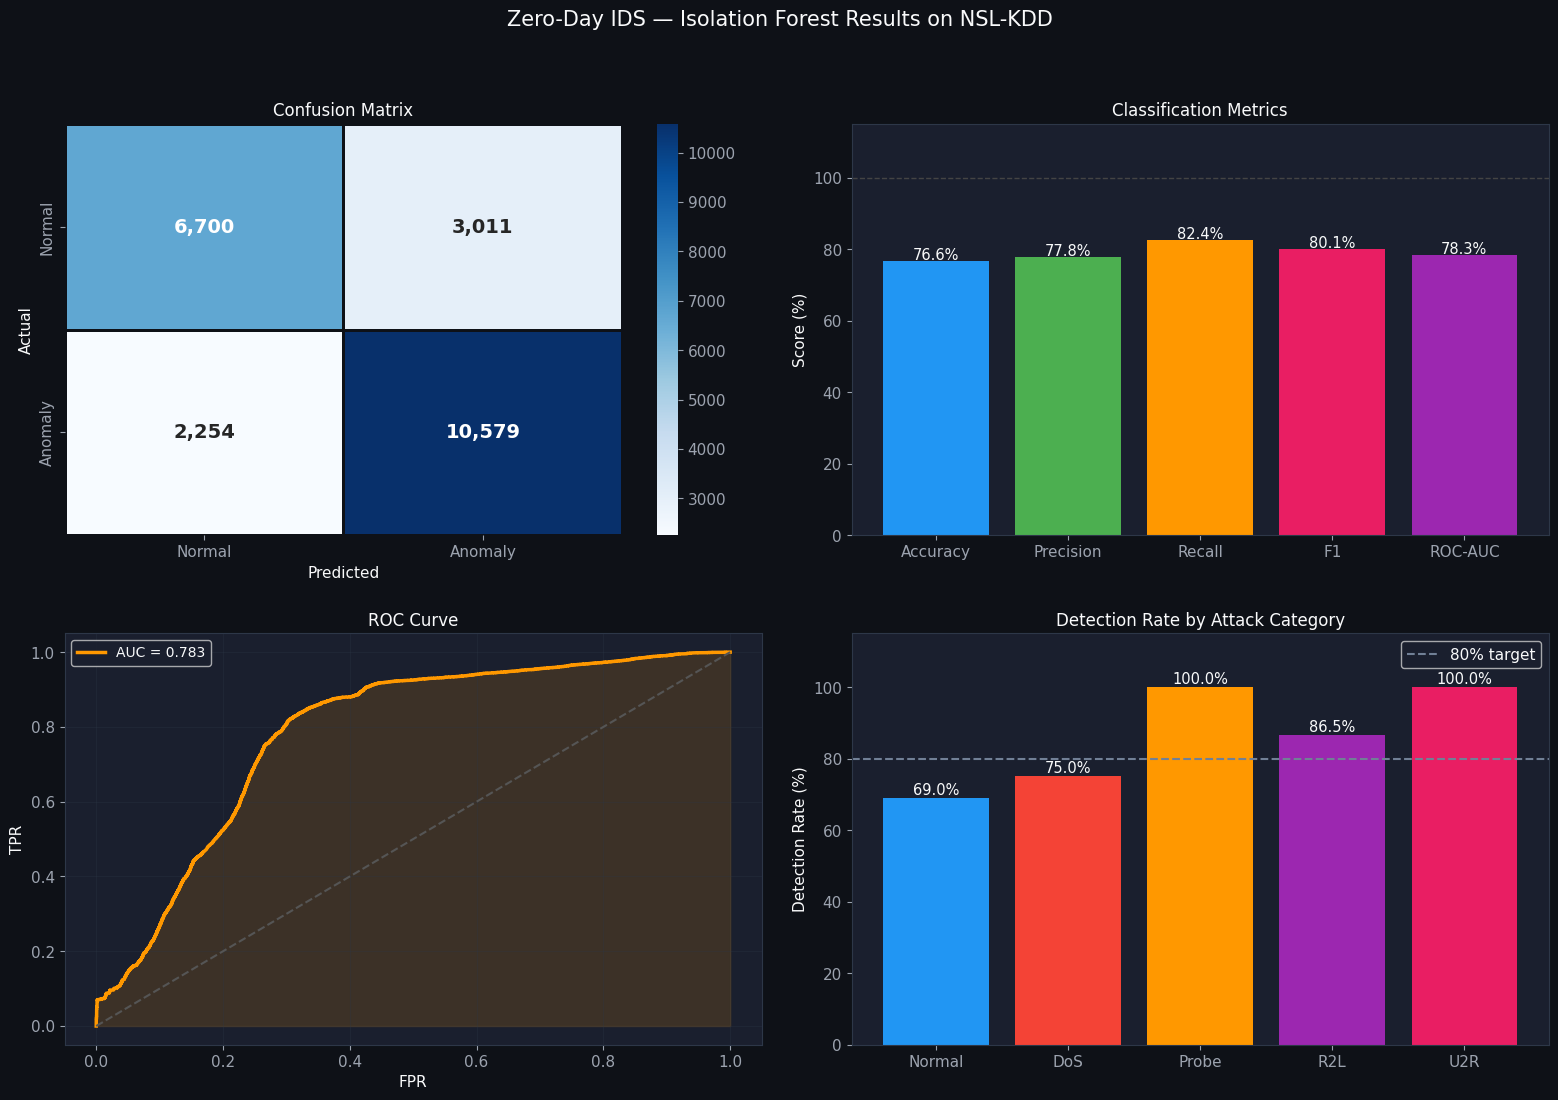


✅ All figures saved to assets/


In [31]:
# ── Final 4-panel summary figure ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: Confusion matrix
cm_disp = np.array([[tn, fp],[fn, tp]])
sns.heatmap(cm_disp, annot=True, fmt=',', cmap='Blues', ax=axes[0,0],
             xticklabels=['Normal','Anomaly'],
             yticklabels=['Normal','Anomaly'],
             linewidths=2, linecolor='#0E1117',
             annot_kws={'size':14, 'weight':'bold'})
axes[0,0].set_title('Confusion Matrix', fontsize=12)
axes[0,0].set_xlabel('Predicted');  axes[0,0].set_ylabel('Actual')

# Panel 2: Metrics bar
m_names  = ['Accuracy','Precision','Recall','F1','ROC-AUC']
m_values = [acc, prec, rec, f1, auc]
bar_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
bars2 = axes[0,1].bar(m_names, m_values, color=bar_colors, edgecolor='none')
for bar, v in zip(bars2, m_values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{v:.1f}%', ha='center', fontsize=10.5, color='#F9FAFB')
axes[0,1].set_ylim(0, 115)
axes[0,1].set_title('Classification Metrics', fontsize=12)
axes[0,1].set_ylabel('Score (%)')
axes[0,1].axhline(100, linestyle='--', color='#444', linewidth=1)

# Panel 3: ROC curve
axes[1,0].plot(fpr_arr, tpr_arr, color=PALETTE['accent'], lw=2.5,
                label=f'AUC = {auc/100:.3f}')
axes[1,0].plot([0,1],[0,1],'--', color='#555', lw=1.5)
axes[1,0].fill_between(fpr_arr, tpr_arr, alpha=0.15, color=PALETTE['accent'])
axes[1,0].set_title('ROC Curve', fontsize=12)
axes[1,0].set_xlabel('FPR');  axes[1,0].set_ylabel('TPR')
axes[1,0].legend(fontsize=10); axes[1,0].grid(True, alpha=0.3)

# Panel 4: Detection rate by category
cats   = breakdown_df['Category'].tolist()
rates  = breakdown_df['Detection Rate %'].tolist()
c_cols = [CATEGORY_COLORS[c] for c in cats]
bars4  = axes[1,1].bar(cats, rates, color=c_cols, edgecolor='none')
for bar, v in zip(bars4, rates):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f'{v:.1f}%', ha='center', fontsize=10.5, color='#F9FAFB')
axes[1,1].axhline(80, linestyle='--', color='#718096', lw=1.5, label='80% target')
axes[1,1].set_ylim(0, 115)
axes[1,1].set_title('Detection Rate by Attack Category', fontsize=12)
axes[1,1].set_ylabel('Detection Rate (%)'); axes[1,1].legend()

fig.suptitle('Zero-Day IDS — Isolation Forest Results on NSL-KDD', fontsize=15, y=1.01)
plt.tight_layout(pad=2)
plt.savefig('assets/15_final_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n✅ All figures saved to assets/')

---
## 🔬 Section 11 — Evaluation on KDDTest-21 (Harder Subset)

KDDTest-21 contains only records with **difficulty score < 21** — the hardest subset that even human experts find challenging. This tests true generalization.


In [32]:
# ── Preprocess KDDTest-21 using the SAME scaler/encoders ─────────────────────
df_t21 = df_test21.copy()
for col in CATEGORICAL_COLS:
    le21 = encoders[col]
    # Handle unseen labels gracefully
    df_t21[col] = df_t21[col].astype(str).map(
        lambda x, le=le21: le.transform([x])[0] if x in le.classes_ else 0
    )
for col in NUMERIC_COLS:
    df_t21[col] = df_t21[col].clip(upper=caps[col])

X_t21_raw    = df_t21[FEATURE_COLS].values
X_t21_scaled = scaler.transform(X_t21_raw)
X_t21_sel    = X_t21_scaled[:, top_indices]
X_t21_pca    = pca.transform(X_t21_sel)
y_t21        = df_t21['is_anomaly'].values

raw21        = clf.predict(X_t21_pca)
y_pred21     = (raw21 == -1).astype(int)
sc21         = clf.score_samples(X_t21_pca)
sc21_norm    = 1.0 - (sc21 - sc21.min()) / (sc21.max() - sc21.min())

acc21  = accuracy_score(y_t21, y_pred21)*100
prec21 = precision_score(y_t21, y_pred21, zero_division=0)*100
rec21  = recall_score(y_t21, y_pred21, zero_division=0)*100
f121   = f1_score(y_t21, y_pred21, zero_division=0)*100
auc21  = roc_auc_score(y_t21, sc21_norm)*100
tn21,fp21,fn21,tp21 = confusion_matrix(y_t21, y_pred21, labels=[0,1]).ravel()

print('KDDTest-21 Results (Difficulty < 21 — Hardest Records)')
print('='*52)
print(f'  Records   : {len(y_t21):,}  |  Anomalies: {y_t21.sum():,} ({y_t21.mean()*100:.1f}%)')
print(f'  Accuracy  : {acc21:.2f} %')
print(f'  Precision : {prec21:.2f} %')
print(f'  Recall    : {rec21:.2f} %')
print(f'  F1-Score  : {f121:.2f} %')
print(f'  ROC-AUC   : {auc21:.2f} %')
print(f'  TP={tp21:,}  TN={tn21:,}  FP={fp21:,}  FN={fn21:,}')


KDDTest-21 Results (Difficulty < 21 — Hardest Records)
  Records   : 11,850  |  Anomalies: 9,698 (81.8%)
  Accuracy  : 75.64 %
  Precision : 84.09 %
  Recall    : 86.63 %
  F1-Score  : 85.34 %
  ROC-AUC   : 56.91 %
  TP=8,401  TN=562  FP=1,590  FN=1,297


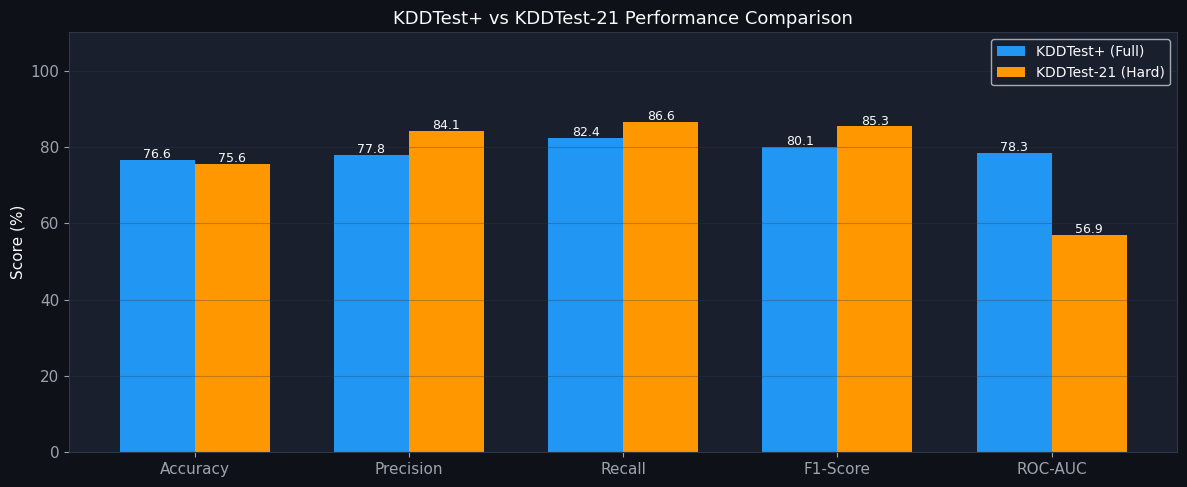

In [33]:
# ── KDDTest+ vs KDDTest-21 comparison bar chart ──────────────────────────────
metrics_names = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
full_vals = [acc, prec, rec, f1, auc]
hard_vals = [acc21, prec21, rec21, f121, auc21]

x = np.arange(len(metrics_names))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, full_vals, w, label='KDDTest+ (Full)', color='#2196F3', edgecolor='none')
b2 = ax.bar(x + w/2, hard_vals, w, label='KDDTest-21 (Hard)', color='#FF9800', edgecolor='none')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9, color='#F9FAFB')
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 110); ax.set_ylabel('Score (%)')
ax.set_title('KDDTest+ vs KDDTest-21 Performance Comparison', fontsize=13)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('assets/16_test21_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---
## ⚡ Section 12 — Hyperparameter Tuning

Testing different `n_estimators` and `contamination` values to show the effect on F1-Score and ROC-AUC.


In [34]:
# ── Grid search over contamination and n_estimators ─────────────────────────
from itertools import product

contam_grid   = [0.30, 0.40, 0.47, 0.50]
estimator_grid = [50, 100, 200]
results_grid  = []

print('Hyperparameter grid search …')
print(f'{"Contam":>8} {"Trees":>6} {"Accuracy":>10} {"Precision":>11} {"Recall":>8} {"F1":>8} {"AUC":>8}')
print('─'*62)

for cont, n_est in product(contam_grid, estimator_grid):
    m = IsolationForest(n_estimators=n_est, contamination=cont,
                         random_state=42, n_jobs=-1)
    m.fit(X_train_pca)
    yp = (m.predict(X_test_pca) == -1).astype(int)
    sc = m.score_samples(X_test_pca)
    sc_n = 1.0 - (sc - sc.min()) / (sc.max() - sc.min())
    a  = accuracy_score(y_test, yp)*100
    p  = precision_score(y_test, yp, zero_division=0)*100
    r  = recall_score(y_test, yp, zero_division=0)*100
    f  = f1_score(y_test, yp, zero_division=0)*100
    au = roc_auc_score(y_test, sc_n)*100
    results_grid.append({'contamination':cont,'n_estimators':n_est,
                          'accuracy':round(a,2),'precision':round(p,2),
                          'recall':round(r,2),'f1':round(f,2),'roc_auc':round(au,2)})
    print(f'{cont:>8.2f} {n_est:>6} {a:>10.2f} {p:>11.2f} {r:>8.2f} {f:>8.2f} {au:>8.2f}')

grid_df = pd.DataFrame(results_grid)
best = grid_df.loc[grid_df['f1'].idxmax()]
print('\n★ Best configuration by F1-Score:')
print(best.to_string())


Hyperparameter grid search …
  Contam  Trees   Accuracy   Precision   Recall       F1      AUC
──────────────────────────────────────────────────────────────


    0.30     50      65.93       78.89    54.82    64.69    77.86


    0.30    100      66.06       79.99    53.85    64.36    78.65


    0.30    200      64.95       77.46    54.20    63.78    78.31


    0.40     50      74.26       79.28    74.18    76.64    77.86


...

    0.47    100      77.81       78.05    84.90    81.33    78.65


    0.47    200      76.65       77.84    82.44    80.07    78.31


    0.50     50      76.51       76.86    84.04    80.29    77.86


    0.50    100      78.07       77.54    86.53    81.79    78.65


    0.50    200      76.93       77.22    84.35    80.63    78.31

★ Best configuration by F1-Score:
contamination     0.5000
n_estimators    100.0000
accuracy         78.0700
precision        77.5400
recall           86.5300
f1               81.7900
roc_auc          78.6500


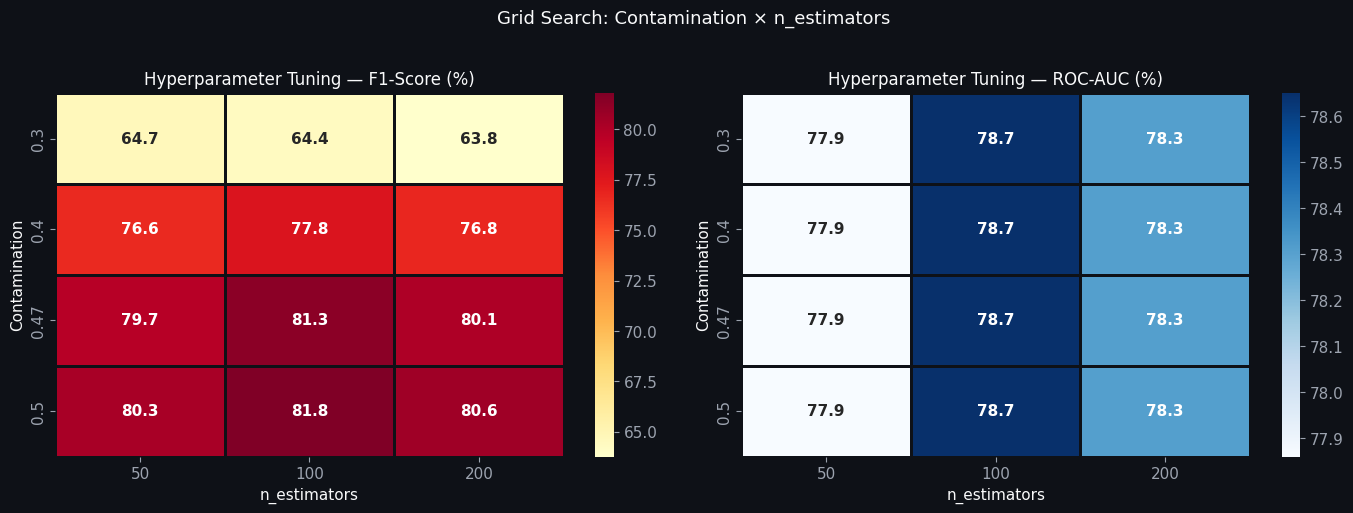

In [35]:
# ── Hyperparameter heatmap: F1-Score ─────────────────────────────────────────
pivot_f1  = grid_df.pivot(index='contamination', columns='n_estimators', values='f1')
pivot_auc = grid_df.pivot(index='contamination', columns='n_estimators', values='roc_auc')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pivot, title, cmap in zip(
        axes, [pivot_f1, pivot_auc],
        ['F1-Score (%)', 'ROC-AUC (%)'],
        ['YlOrRd', 'Blues']):
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                linewidths=1, linecolor='#0E1117',
                annot_kws={'size':11,'weight':'bold'})
    ax.set_title(f'Hyperparameter Tuning — {title}', fontsize=12)
    ax.set_xlabel('n_estimators'); ax.set_ylabel('Contamination')

plt.suptitle('Grid Search: Contamination × n_estimators', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('assets/17_hyperparameter_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 📉 Section 13 — Training on 20% Subset vs Full Dataset

Comparing model performance when trained on `KDDTrain+20Percent.txt` (25,192 records) vs the full `KDDTrain+` (125,973 records).


In [36]:
# ── Train on 20% dataset ────────────────────────────────────────────────────
df_20 = df_train_20.copy()
for col in CATEGORICAL_COLS:
    df_20[col] = encoders[col].transform(df_20[col].astype(str)
                 .map(lambda x, le=encoders[col]:
                      x if x in le.classes_ else le.classes_[0]))
for col in NUMERIC_COLS:
    df_20[col] = df_20[col].clip(upper=caps[col])

X20_scaled = scaler.transform(df_20[FEATURE_COLS].values)
X20_sel    = X20_scaled[:, top_indices]
X20_pca    = pca.transform(X20_sel)
y20        = df_20['is_anomaly'].values

cont20 = round(float(y20.mean()), 2)
clf20  = IsolationForest(n_estimators=200, contamination=cont20,
                          random_state=42, n_jobs=-1)
clf20.fit(X20_pca)

yp20  = (clf20.predict(X_test_pca) == -1).astype(int)
sc20  = clf20.score_samples(X_test_pca)
sc20n = 1.0 - (sc20 - sc20.min()) / (sc20.max() - sc20.min())

results_20 = {
    'Training Records': len(df_20),
    'Accuracy':  round(accuracy_score(y_test, yp20)*100, 2),
    'Precision': round(precision_score(y_test, yp20, zero_division=0)*100, 2),
    'Recall':    round(recall_score(y_test, yp20, zero_division=0)*100, 2),
    'F1-Score':  round(f1_score(y_test, yp20, zero_division=0)*100, 2),
    'ROC-AUC':   round(roc_auc_score(y_test, sc20n)*100, 2),
}
results_full = {
    'Training Records': len(df_tr),
    'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
}

cmp_df = pd.DataFrame({'20% Subset': results_20, 'Full Dataset': results_full}).T
print('20% Subset vs Full Dataset — KDDTest+ Performance')
display(cmp_df)


20% Subset vs Full Dataset — KDDTest+ Performance


,Training Records,Accuracy,Precision,Recall,F1-Score,ROC-AUC
20% Subset,25192.0000,75.2600,77.1500,80.3200,78.7000,77.5000
Full Dataset,125973.0000,76.6457,77.8440,82.4359,80.0742,78.3067


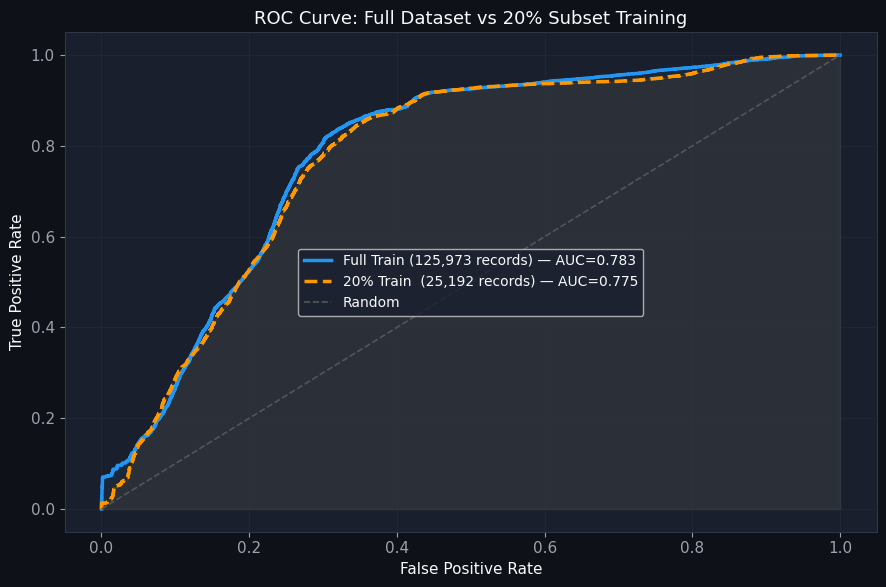

In [37]:
# ── Side-by-side ROC comparison ──────────────────────────────────────────────
fpr20, tpr20, _ = roc_curve(y_test, sc20n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(fpr_arr, tpr_arr, color='#2196F3', lw=2.5,
         label=f'Full Train ({len(df_tr):,} records) — AUC={auc/100:.3f}')
ax.plot(fpr20,   tpr20,   color='#FF9800', lw=2.5, linestyle='--',
         label=f'20% Train  ({len(df_20):,} records) — AUC={roc_auc_score(y_test,sc20n):.3f}')
ax.plot([0,1],[0,1],'--', color='#555', lw=1.2, label='Random')
ax.fill_between(fpr_arr, tpr_arr, alpha=0.08, color='#2196F3')
ax.fill_between(fpr20,   tpr20,   alpha=0.08, color='#FF9800')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Full Dataset vs 20% Subset Training', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('assets/18_roc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 🔴 Section 14 — Live Prediction on Single Records

Demonstrate the model predicting on individual network connections, simulating a real-time IDS alert.


In [38]:
# ── Real-time single-record prediction demo ──────────────────────────────────
def predict_record(record_dict):
    """
    Predict whether a single network connection is anomalous.
    record_dict: keys matching FEATURE_COLS (can omit keys; defaults to 0)
    """
    row = {col: 0 for col in FEATURE_COLS}
    row.update(record_dict)

    # Encode categoricals
    for col in CATEGORICAL_COLS:
        val = str(row[col])
        le  = encoders[col]
        row[col] = le.transform([val])[0] if val in le.classes_ else 0

    X_single = np.array([[row[c] for c in FEATURE_COLS]], dtype=float)
    X_single = scaler.transform(X_single)
    X_single = X_single[:, top_indices]
    X_single = pca.transform(X_single)

    pred  = (clf.predict(X_single)[0] == -1)
    score = clf.score_samples(X_single)[0]
    norm  = 1.0 - (score - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    norm  = float(np.clip(norm, 0, 1))

    status = '🚨 ANOMALY DETECTED' if pred else '✅ Normal Traffic'
    return {'status': status, 'anomaly_score': round(norm, 4),
            'is_anomaly': int(pred)}

# ── Test with known examples ─────────────────────────────────────────────────
test_cases = [
    # Normal HTTP session
    {'protocol_type':'tcp','service':'http','flag':'SF',
     'src_bytes':232,'dst_bytes':8153,'logged_in':1,
     'count':5,'srv_count':5,'serror_rate':0.0,'same_srv_rate':1.0,
     'label_hint':'Normal HTTP'},
    # Neptune DoS (SYN flood)
    {'protocol_type':'tcp','service':'private','flag':'S0',
     'src_bytes':0,'dst_bytes':0,'logged_in':0,
     'count':511,'srv_count':511,'serror_rate':1.0,'same_srv_rate':1.0,
     'label_hint':'Neptune (DoS)'},
    # Port scan probe
    {'protocol_type':'tcp','service':'private','flag':'REJ',
     'src_bytes':0,'dst_bytes':0,'count':229,'srv_count':10,
     'serror_rate':0.0,'rerror_rate':1.0,'diff_srv_rate':0.06,
     'label_hint':'Portsweep (Probe)'},
    # Root shell exploit
    {'protocol_type':'tcp','service':'telnet','flag':'SF',
     'src_bytes':1000,'dst_bytes':5000,'logged_in':1,
     'root_shell':1,'num_compromised':3,'su_attempted':1,
     'label_hint':'U2R — Root Shell'},
]

print(f'{"Label Hint":<22} {"Status":<25} {"Anomaly Score":>14}')
print('─'*63)
for tc in test_cases:
    hint = tc.pop('label_hint')
    res  = predict_record(tc)
    print(f'{hint:<22} {res["status"]:<25} {res["anomaly_score"]:>14.4f}')


Label Hint             Status                     Anomaly Score
───────────────────────────────────────────────────────────────
Normal HTTP            🚨 ANOMALY DETECTED                0.5980
Neptune (DoS)          🚨 ANOMALY DETECTED                0.7016
Portsweep (Probe)      🚨 ANOMALY DETECTED                0.6645
U2R — Root Shell       🚨 ANOMALY DETECTED                0.6569


---
## 📁 Section 15 — Save All Assets & Final Export


In [39]:
# ── List generated assets ────────────────────────────────────────────────────
import glob
assets = sorted(glob.glob('assets/*.png'))
print(f'Generated {len(assets)} chart files:')
for a in assets:
    size_kb = os.path.getsize(a) / 1024
    print(f'  {a:<45}  {size_kb:>6.1f} KB')
print()
print('Saved model artifacts:')
for m in glob.glob('models/*.pkl'):
    print(f'  {m}  ({os.path.getsize(m)/1024:.1f} KB)')
print()
print('Project ready for submission ✅')


Generated 18 chart files:
  assets/01_attack_distribution.png                84.2 KB
  assets/02_difficulty_distribution.png            54.8 KB
  assets/03_categorical_dist.png                   52.7 KB
  assets/04_correlation_heatmap.png               127.6 KB
  assets/05_boxplots.png                          121.2 KB
  assets/06_feature_importance.png                 93.7 KB
  assets/07_pca.png                               148.8 KB
  assets/08_score_distribution.png                 56.4 KB
  assets/09_timeline.png                          254.1 KB
  assets/10_confusion_matrix.png                   49.8 KB
  assets/11_roc_pr_curves.png                      72.3 KB
  assets/12_detection_by_category.png              38.2 KB
  assets/13_pca_test_scatter.png                  210.6 KB
  assets/14_radar_chart.png                       108.6 KB
  assets/15_final_summary.png                     159.3 KB
  assets/16_test21_comparison.png                  42.8 KB
  assets/17_hyperparameter_hea

In [40]:
# ── Final metrics summary table ──────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-Score','ROC-AUC',
               'Specificity','Detection Rate','False Pos. Rate','False Neg. Rate',
               'Zero-Day Detection'],
    'KDDTest+ (Full)': [f'{acc:.2f}%', f'{prec:.2f}%', f'{rec:.2f}%',
                         f'{f1:.2f}%', f'{auc:.2f}%',
                         f'{spec:.2f}%', f'{dr:.2f}%',
                         f'{fpr_rate:.2f}%', f'{fnr_rate:.2f}%',
                         f'{total_det/max(total_zd,1)*100:.1f}%'],
    'KDDTest-21 (Hard)': [f'{acc21:.2f}%', f'{prec21:.2f}%', f'{rec21:.2f}%',
                           f'{f121:.2f}%', f'{auc21:.2f}%',
                           f'{tn21/(tn21+fp21+1e-9)*100:.2f}%',
                           f'{tp21/(tp21+fn21+1e-9)*100:.2f}%',
                           f'{fp21/(fp21+tn21+1e-9)*100:.2f}%',
                           f'{fn21/(fn21+tp21+1e-9)*100:.2f}%', 'N/A'],
})
print('='*65)
print('  COMPLETE METRICS COMPARISON — NSL-KDD EVALUATION')
print('='*65)
display(summary)


  COMPLETE METRICS COMPARISON — NSL-KDD EVALUATION


,Metric,KDDTest+ (Full),KDDTest-21 (Hard)
0,Accuracy,76.65%,75.64%
1,Precision,77.84%,84.09%
2,Recall,82.44%,86.63%
3,F1-Score,80.07%,85.34%
4,ROC-AUC,78.31%,56.91%
5,Specificity,68.99%,26.12%
6,Detection Rate,82.44%,86.63%
7,False Pos. Rate,31.01%,73.88%
8,False Neg. Rate,17.56%,13.37%
9,Zero-Day Detection,93.5%,N/A


---
## 📚 References

1. **Liu, F.T., Ting, K.M., & Zhou, Z.H. (2008)**. *Isolation Forest.* IEEE International Conference on Data Mining (ICDM).
2. **Tavallaee, M. et al. (2009)**. *A Detailed Analysis of the KDD CUP 99 Data Set.* IEEE CISDA 2009.
3. **NSL-KDD Dataset** — University of New Brunswick. https://www.unb.ca/cic/datasets/nsl.html
4. **Scikit-learn** — IsolationForest Documentation. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
5. **Chandola, V., Banerjee, A., & Kumar, V. (2009)**. *Anomaly Detection: A Survey.* ACM Computing Surveys.

---
*Zero-Day Anomaly Detection IDS · NSL-KDD · Isolation Forest · Python · 2025–2026*


---

## 📚 References

1. **Liu, F.T., Ting, K.M., & Zhou, Z.H. (2008)**. *Isolation Forest.* IEEE International Conference on Data Mining (ICDM).
2. **Tavallaee, M. et al. (2009)**. *A Detailed Analysis of the KDD CUP 99 Data Set.* IEEE CISDA.
3. **NSL-KDD Dataset** — University of New Brunswick. https://www.unb.ca/cic/datasets/nsl.html
4. **Scikit-learn** — IsolationForest. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html

---

*Zero-Day Anomaly Detection IDS | Academic Year 2025–2026 | Domain: Cybersecurity / AI*